# Power Outage Forecasting
This notebook is a demo for how to load, process, train on, and produce prediction files with the provided dataset.
You should not be confined by this notebook, but highly encouraged to produce your own pipeline or models based on what you learned from the course.

The format of submission files, however, is VERY strict. Student have to follow the provided tempaltes and the submitted files must pass the sanity tests in the last section.

Note the test files loaded in this notebook contain random noise. They only serve the purpose to dmostrate how evalution will be done. The actual test file has been hidden.

It is encouraged to run the starter notebook in Google Colab for easy of debug and implementation. You could also use your local Python notebook.
There is a chance that you run into out of memory when running this demo notebook in Colab free tier. In that case, you could either apply for free Google Colab Pro subscription as student and turn on high RAM, or only run one of the three models (all of the SARIMAX models, Seq2seq model for 24h, or Seq2seq model for 48h) included in the notebook.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
%cd /content/drive/MyDrive/MLPSproject/dataset
!ls

/content/drive/MyDrive/MLPSproject/dataset
 data		   demo.ipynb			 submission_template_48h.csv
'demo (1).ipynb'   submission_template_24h.csv


## Prerequisites & Installation

Before running this demo notebook, ensure you have the required packages installed:

- `xarray` - for reading NetCDF files
- `netCDF4` - backend for xarray
- `numpy` - numerical operations
- `pandas` - data manipulation
- `matplotlib` - visualization
- `torch` - deep learning (PyTorch)
- `statsmodels` - SARIMAX models
- `tqdm` - progress bars


In [6]:
# if you are first time running this notebook on Colab, you might need this:

# Install the netCDF4 library using pip
!pip install netCDF4

In [7]:
# Check dependencies
import sys

required_packages = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'xarray': 'xarray',
    'netCDF4': 'netCDF4',
    'matplotlib': 'matplotlib',
    'torch': 'torch',
    'statsmodels': 'statsmodels',
    'tqdm': 'tqdm'
}

missing_packages = []
for package_name, import_name in required_packages.items():
    try:
        __import__(import_name)
        print(f"✓ {package_name} is installed")
    except ImportError as e:
        print(f"✗ {package_name} is NOT installed - {str(e)}")
        missing_packages.append(package_name)

if missing_packages:
    print(f"\n⚠️  Missing packages: {', '.join(missing_packages)}")
else:
    print("\n✓ All required packages are installed!")

✓ numpy is installed
✓ pandas is installed
✓ xarray is installed
✓ netCDF4 is installed
✓ matplotlib is installed
✓ torch is installed
✓ statsmodels is installed
✓ tqdm is installed

✓ All required packages are installed!


## 1. Configuration & Setup

Define all meta variables and parameters at the start for easy configuration.

In [8]:
# ============== META VARIABLES ==============
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Data paths
DATA_DIR = "data/"
RESULTS_DIR = "results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, "train.nc")

# The test_24h_demo.nc and test_48h_demo.nc are just demo files, so the outages in those files are just noise
# TEST_24H_PATH = os.path.join(DATA_DIR, "test_24h.nc")
# TEST_48H_PATH = os.path.join(DATA_DIR, "test_48h.nc")
TEST_24H_PATH = os.path.join(DATA_DIR, "test_24h_demo.nc")
TEST_48H_PATH = os.path.join(DATA_DIR, "test_48h_demo.nc")

# Model parameters
VALIDATION_SPLIT = 0.2  # Use last 20% of training data for validation

# SARIMAX parameters
SARIMAX_ORDER = (1, 0, 1)  # (p, d, q)

# Seq2Seq parameters
SEQ_LEN = 24       # Lookback window (hours) for the seq2seq model
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 1e-3
HIDDEN_DIM = 64
NUM_LAYERS = 1

# Set device for PyTorch
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Configuration loaded successfully!")
print(f"Random Seed: {RANDOM_SEED}")
print(f"Device: {DEVICE}")
print(f"Data Directory: {DATA_DIR}")
print(f"Results Directory: {RESULTS_DIR}")

Configuration loaded successfully!
Random Seed: 42
Device: cpu
Data Directory: data/
Results Directory: results/


## 2. Data Loading

Load the NetCDF datasets and explore their structure.

In [9]:
# Load datasets
ds_train = xr.open_dataset(TRAIN_PATH)
ds_test_24h = xr.open_dataset(TEST_24H_PATH)
ds_test_48h = xr.open_dataset(TEST_48H_PATH)

In [10]:
# Extract basic information
train_timestamps = pd.to_datetime(ds_train.timestamp.values)
locations = list(ds_train.location.values)
weather_features = list(ds_train.feature.values) if 'feature' in ds_train.dims else []

print(f"Training Period: {train_timestamps.min()} to {train_timestamps.max()}")
print(f"Number of Timestamps: {len(train_timestamps)}")
print(f"Number of Locations: {len(locations)}")
print(f"Locations: {locations}")
print(f"\nWeather Features ({len(weather_features)}): {weather_features}")

# Extract outage data
outage_data = ds_train.out.transpose("timestamp", "location").values.astype(float)
print(f"\nOutage Data Shape: {outage_data.shape} (timestamps x locations)")
print(f"Outage Statistics:")
print(f"  Mean: {np.nanmean(outage_data):.2f}")
print(f"  Std: {np.nanstd(outage_data):.2f}")
print(f"  Min: {np.nanmin(outage_data):.2f}")
print(f"  Max: {np.nanmax(outage_data):.2f}")

Training Period: 2023-04-01 00:00:00 to 2023-06-30 00:00:00
Number of Timestamps: 2161
Number of Locations: 83
Locations: [np.str_('26001'), np.str_('26003'), np.str_('26005'), np.str_('26007'), np.str_('26009'), np.str_('26011'), np.str_('26013'), np.str_('26015'), np.str_('26017'), np.str_('26019'), np.str_('26021'), np.str_('26023'), np.str_('26025'), np.str_('26027'), np.str_('26029'), np.str_('26031'), np.str_('26033'), np.str_('26035'), np.str_('26037'), np.str_('26039'), np.str_('26041'), np.str_('26043'), np.str_('26045'), np.str_('26047'), np.str_('26049'), np.str_('26051'), np.str_('26053'), np.str_('26055'), np.str_('26057'), np.str_('26059'), np.str_('26061'), np.str_('26063'), np.str_('26065'), np.str_('26067'), np.str_('26069'), np.str_('26071'), np.str_('26073'), np.str_('26075'), np.str_('26077'), np.str_('26079'), np.str_('26081'), np.str_('26083'), np.str_('26085'), np.str_('26087'), np.str_('26089'), np.str_('26091'), np.str_('26093'), np.str_('26095'), np.str_('2609

In [11]:
# Load test datasets
print("Loading test datasets...")

test_24h_timestamps = ds_test_24h.timestamp.values
test_48h_timestamps = ds_test_48h.timestamp.values

print(f"✓ Test 24h: {len(test_24h_timestamps)} timestamps")
print(f"✓ Test 48h: {len(test_48h_timestamps)} timestamps")

print(f"\nTesting Period (24h): {test_24h_timestamps.min()} to {test_24h_timestamps.max()}")
print(f"Testing Period (48h): {test_48h_timestamps.min()} to {test_48h_timestamps.max()}")

Loading test datasets...
✓ Test 24h: 24 timestamps
✓ Test 48h: 48 timestamps

Testing Period (24h): 2023-06-30T01:00:00.000000000 to 2023-07-01T00:00:00.000000000
Testing Period (48h): 2023-06-30T01:00:00.000000000 to 2023-07-02T00:00:00.000000000


In [12]:
# sanity check on outage being positive and smaller than total tracked household
print(bool((ds_train.out <= ds_train.tracked).all()))
print(bool((ds_train.out>=0).all()))
print(bool((ds_train.tracked>=0).all()))

True
True
True


## 3. Exploratory Data Analysis

EDA is important for you to understand the data and the problem. Here I just show some basics.

Top 5 locations by population: ['26163', '26125', '26099', '26081', '26049']


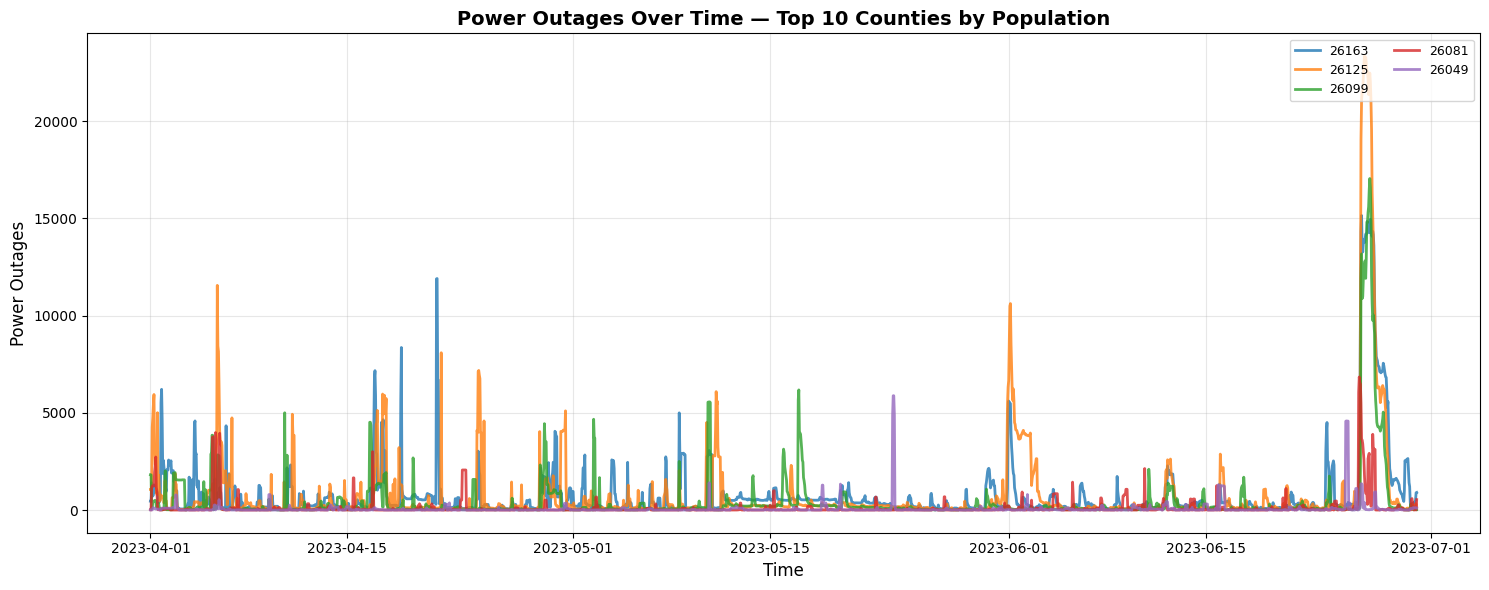

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Compute population per county
pop_by_loc = ds_train.tracked.mean(dim="timestamp")

# 2) Get top 10 locations by population
top5_locs = (
    pop_by_loc
    .sortby(pop_by_loc, ascending=False)
    .isel(location=slice(0, 5))
    .location
    .values
)

print("Top 5 locations by population:", [str(x) for x in top5_locs])

# 3) Plot their outages over time
fig, ax = plt.subplots(figsize=(15, 6))

for loc in top5_locs:
    outages = ds_train.out.sel(location=loc).values
    ax.plot(train_timestamps, outages, label=str(loc), alpha=0.8, linewidth=2)

ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Power Outages", fontsize=12)
ax.set_title("Power Outages Over Time — Top 10 Counties by Population",
             fontsize=14, fontweight="bold")
ax.legend(ncol=2, fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


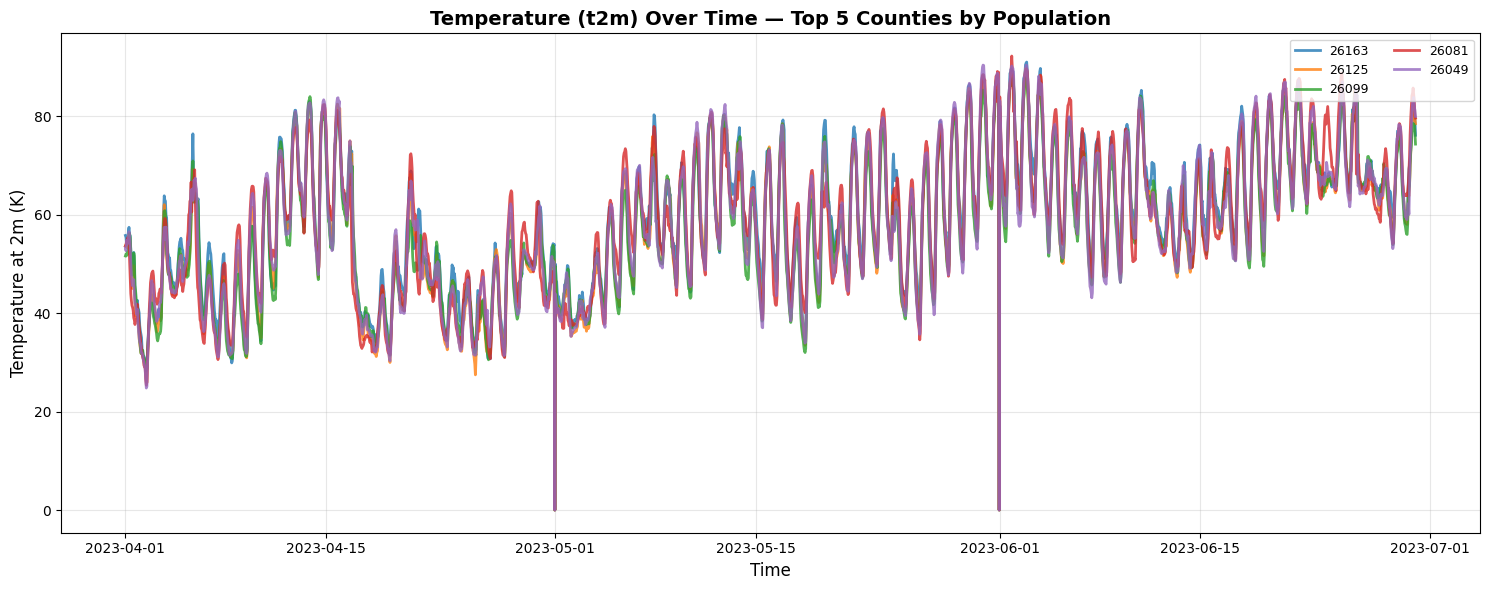


t2m Statistics for Top 5 Counties:
  26163: Mean=59.44K, Min=0.00K, Max=90.98K
  26125: Mean=57.77K, Min=0.00K, Max=89.62K
  26099: Mean=57.13K, Min=0.00K, Max=87.82K
  26081: Mean=58.61K, Min=0.00K, Max=92.21K
  26049: Mean=58.07K, Min=0.00K, Max=90.36K


In [14]:
# Get the feature index for t2m
t2m_idx = weather_features.index('t2m')

fig, ax = plt.subplots(figsize=(15, 6))

# Plot t2m for the top 5 counties
for loc in top5_locs:
    # Extract t2m data for this location: (timestamp, feature) -> select t2m
    t2m_data = ds_train.weather.sel(location=loc, feature='t2m').values
    ax.plot(train_timestamps, t2m_data, label=str(loc), alpha=0.8, linewidth=2)

ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Temperature at 2m (K)", fontsize=12)
ax.set_title("Temperature (t2m) Over Time — Top 5 Counties by Population",
                fontsize=14, fontweight="bold")
ax.legend(ncol=2, fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print some statistics
print("\nt2m Statistics for Top 5 Counties:")
for loc in top5_locs:
    t2m_data = ds_train.weather.sel(location=loc, feature='t2m').values
    print(f"  {loc}: Mean={np.mean(t2m_data):.2f}K, "
            f"Min={np.min(t2m_data):.2f}K, Max={np.max(t2m_data):.2f}K")

Correlation Analysis: t2m (Temperature) vs. Power Outages

County 26163:
  Correlation: +0.0470 (Positive)
  Sample size: 2161 valid data points

County 26125:
  Correlation: +0.0671 (Positive)
  Sample size: 2161 valid data points

County 26099:
  Correlation: +0.0743 (Positive)
  Sample size: 2161 valid data points

County 26081:
  Correlation: +0.0306 (Positive)
  Sample size: 2161 valid data points

County 26049:
  Correlation: +0.1182 (Positive)
  Sample size: 2161 valid data points



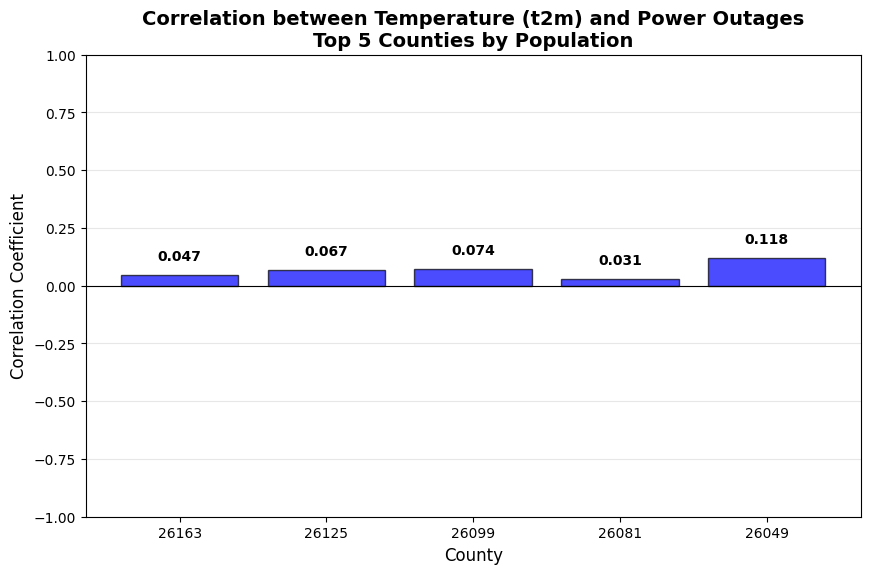

In [15]:
print("Correlation Analysis: t2m (Temperature) vs. Power Outages\n")
print("="*70)

correlations = {}

for loc in top5_locs:
    # Get t2m data
    t2m_data = ds_train.weather.sel(location=loc, feature='t2m').values
    # Get outage data
    outage_data_loc = ds_train.out.sel(location=loc).values

    # Remove NaN values for correlation calculation
    valid_mask = ~(np.isnan(t2m_data) | np.isnan(outage_data_loc))
    t2m_clean = t2m_data[valid_mask]
    outage_clean = outage_data_loc[valid_mask]

    # Calculate Pearson correlation
    if len(t2m_clean) > 1:
        correlation = np.corrcoef(t2m_clean, outage_clean)[0, 1]
        correlations[str(loc)] = correlation

        direction = "Positive" if correlation > 0 else "Negative"

        print(f"County {loc}:")
        print(f"  Correlation: {correlation:+.4f} ({direction})")
        print(f"  Sample size: {len(t2m_clean)} valid data points")
        print()
    else:
        print(f"County {loc}: Insufficient data for correlation")
        correlations[str(loc)] = np.nan

# Visualize correlations
fig, ax = plt.subplots(figsize=(10, 6))

counties_list = list(correlations.keys())
corr_values = list(correlations.values())
colors = ['red' if c < 0 else 'blue' for c in corr_values]

bars = ax.bar(counties_list, corr_values, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('County', fontsize=12)
ax.set_ylabel('Correlation Coefficient', fontsize=12)
ax.set_title('Correlation between Temperature (t2m) and Power Outages\nTop 5 Counties by Population',
                fontsize=14, fontweight='bold')
ax.set_ylim(-1, 1)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, corr_values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (0.05 if height > 0 else -0.05),
            f'{val:.3f}', ha='center', va='bottom' if height > 0 else 'top',
            fontsize=10, fontweight='bold')


---
### 3.2 Dataset Overview & Missing Value Check

DATASET OVERVIEW
Training period : 2023-04-01 00:00:00 → 2023-06-30 00:00:00
Total hours     : 2161
Total counties  : 83
Weather features: 109
Weather vars    : ['SBT113', 'SBT114', 'SBT123', 'SBT124', 'aod', 'bgrun', 'blh', 'cape', 'cape_1', 'cfnsf', 'cfrzr', 'cicep', 'cin', 'cnwat', 'cpofp', 'crain', 'csnow', 'd2m', 'fricv', 'frzr', 'fsr', 'gflux', 'gh', 'gh_1', 'gh_2', 'gh_3', 'gh_4', 'gh_5', 'gh_6', 'gh_7', 'gust', 'hail', 'hail_1', 'hail_2', 'hcc', 'ishf', 'lai', 'layth', 'lcc', 'lftx', 'lftx4', 'lsm', 'ltng', 'max_10si', 'mcc', 'mdens', 'mslma', 'mstav', 'orog', 'pcdb', 'plpl', 'prate', 'pres', 'pres_1', 'pres_2', 'pt', 'pwat', 'r', 'r2', 'r_1', 'refc', 'refd', 'refd_1', 'sde', 'sdlwrf', 'sdswrf', 'sdwe', 'sdwe_1', 'sh2', 'siconc', 'slhtf', 'snowc', 'sp', 'ssrun', 'sulwrf', 'suswrf', 't', 't2m', 'tcc', 'tcc_1', 'tcoli', 'tcolw', 'tp', 'u', 'u10', 'unknown', 'unknown_1', 'unknown_2', 'unknown_3', 'unknown_4', 'unknown_5', 'unknown_6', 'unknown_7', 'unknown_8', 'unknown_9', 'ustm',

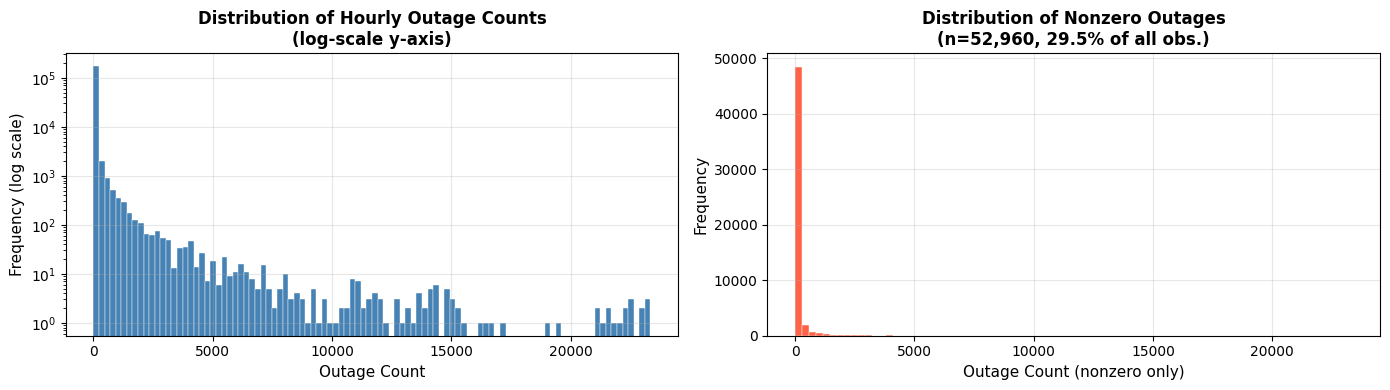

In [16]:
# ── 3.2 Dataset Overview & Missing Value Check ──────────────────────────────
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Training period : {train_timestamps.min()} → {train_timestamps.max()}")
print(f"Total hours     : {len(train_timestamps)}")
print(f"Total counties  : {len(locations)}")
print(f"Weather features: {len(weather_features)}")
print(f"Weather vars    : {weather_features}")

# ── Missing values ───────────────────────────────────────────────────────────
out_vals   = ds_train.out.values           # (T, L)
track_vals = ds_train.tracked.values       # (T, L)
wx_vals    = ds_train.weather.values       # (T, L, F)

out_nan   = int(np.isnan(out_vals).sum())
track_nan = int(np.isnan(track_vals).sum())
wx_nan    = int(np.isnan(wx_vals).sum())
total_out = out_vals.size

print()
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(f"out     : {out_nan:>6} / {total_out}  ({100*out_nan/total_out:.2f}%)")
print(f"tracked : {track_nan:>6} / {total_out}  ({100*track_nan/total_out:.2f}%)")
print(f"weather : {wx_nan:>6} / {wx_vals.size}  ({100*wx_nan/wx_vals.size:.2f}%)")

# ── Distribution of outage counts ────────────────────────────────────────────
flat = out_vals.flatten()
flat_valid = flat[~np.isnan(flat)]

print()
print("=" * 60)
print("OUTAGE COUNT STATISTICS (all county-hours)")
print("=" * 60)
print(f"  Total observations : {len(flat_valid):,}")
print(f"  Zero-outage hours  : {(flat_valid == 0).sum():,}  ({100*(flat_valid==0).mean():.1f}%)")
print(f"  Mean               : {flat_valid.mean():.2f}")
print(f"  Median             : {np.median(flat_valid):.2f}")
print(f"  Std                : {flat_valid.std():.2f}")
print(f"  Max                : {flat_valid.max():.0f}")
print(f"  99th pct           : {np.percentile(flat_valid, 99):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: log-scale histogram (all values)
axes[0].hist(flat_valid, bins=100, log=True, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel("Outage Count", fontsize=11)
axes[0].set_ylabel("Frequency (log scale)", fontsize=11)
axes[0].set_title("Distribution of Hourly Outage Counts\n(log-scale y-axis)", fontweight='bold')
axes[0].grid(True, alpha=0.3)

# right: nonzero only
nz = flat_valid[flat_valid > 0]
axes[1].hist(nz, bins=80, color='tomato', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel("Outage Count (nonzero only)", fontsize=11)
axes[1].set_ylabel("Frequency", fontsize=11)
axes[1].set_title(f"Distribution of Nonzero Outages\n(n={len(nz):,}, {100*len(nz)/len(flat_valid):.1f}% of all obs.)", fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
### 3.3 Temporal Patterns (Hourly & Monthly)

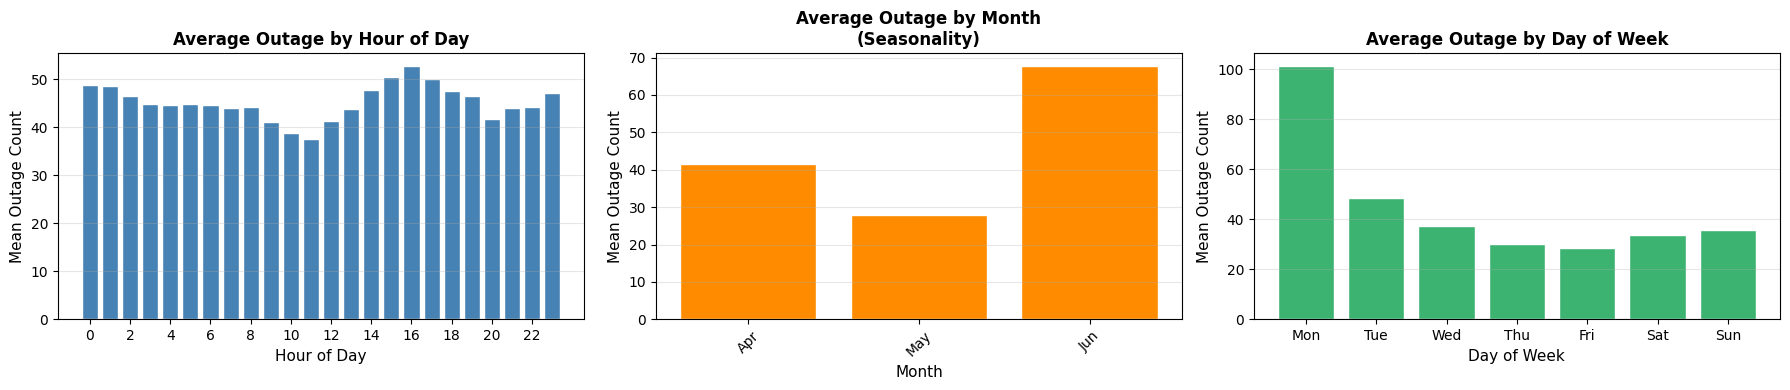

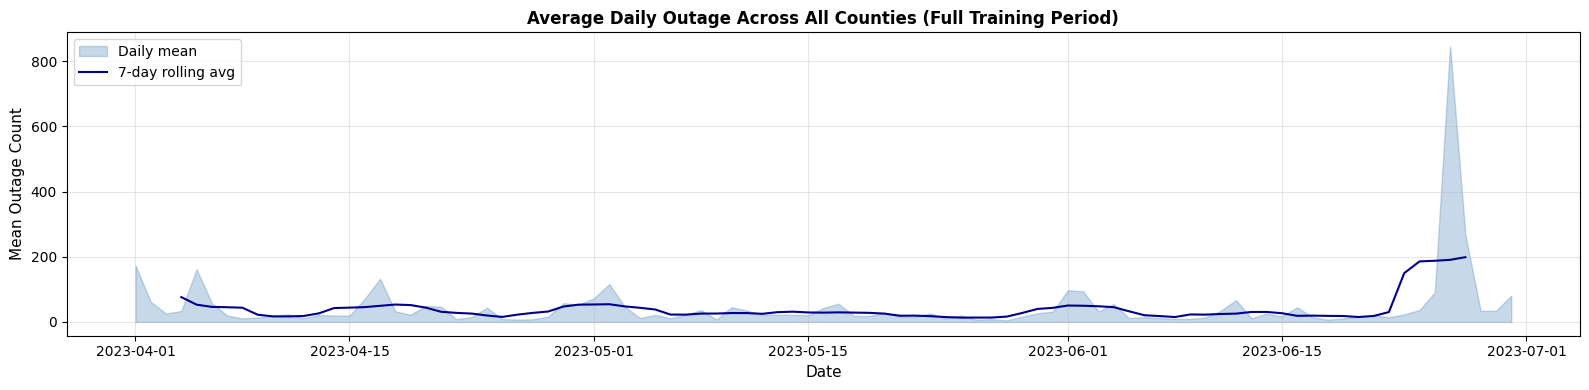

In [17]:
# ── 3.3 Temporal Patterns ────────────────────────────────────────────────────
import pandas as pd

out_df = pd.DataFrame(
    ds_train.out.transpose("timestamp", "location").values,
    index=train_timestamps,
    columns=[str(l) for l in locations]
)
out_df["mean_outage"] = out_df.mean(axis=1)  # average across all counties

# ── Hour-of-day ──────────────────────────────────────────────────────────────
hourly = out_df["mean_outage"].groupby(out_df.index.hour).mean()

# ── Month ────────────────────────────────────────────────────────────────────
monthly = out_df["mean_outage"].groupby(out_df.index.month).mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# ── Day-of-week ──────────────────────────────────────────────────────────────
dow = out_df["mean_outage"].groupby(out_df.index.dayofweek).mean()
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel("Hour of Day", fontsize=11)
axes[0].set_ylabel("Mean Outage Count", fontsize=11)
axes[0].set_title("Average Outage by Hour of Day", fontweight='bold')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(range(len(monthly)), monthly.values, color='darkorange', edgecolor='white')
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels([month_names[m-1] for m in monthly.index], rotation=45)
axes[1].set_xlabel("Month", fontsize=11)
axes[1].set_ylabel("Mean Outage Count", fontsize=11)
axes[1].set_title("Average Outage by Month\n(Seasonality)", fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].bar(range(7), dow.values, color='mediumseagreen', edgecolor='white')
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(dow_names)
axes[2].set_xlabel("Day of Week", fontsize=11)
axes[2].set_ylabel("Mean Outage Count", fontsize=11)
axes[2].set_title("Average Outage by Day of Week", fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── Overall time series (monthly rolling mean) ───────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
daily_mean = out_df["mean_outage"].resample('D').mean()
rolling_7d = daily_mean.rolling(7, center=True).mean()
ax.fill_between(daily_mean.index, daily_mean.values, alpha=0.3, color='steelblue', label='Daily mean')
ax.plot(rolling_7d.index, rolling_7d.values, color='darkblue', linewidth=1.5, label='7-day rolling avg')
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Mean Outage Count", fontsize=11)
ax.set_title("Average Daily Outage Across All Counties (Full Training Period)", fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
### 3.4 Spatial Distribution — All 83 Counties

Top 10 counties by mean outage count:
    County   Mean Out  Outage Rate       Std
----------------------------------------------
     26125     797.72       0.0013   2451.84
     26163     764.81       0.0008   1813.72
     26099     426.03       0.0010   1527.34
     26161     249.88       0.0014   1213.07
     26081     108.07       0.0004    488.14
     26103      98.94       0.0062    621.62
     26145      92.61       0.0010    682.23
     26093      73.81       0.0008    273.45
     26115      69.37       0.0009    252.15
     26049      61.78       0.0003    349.11


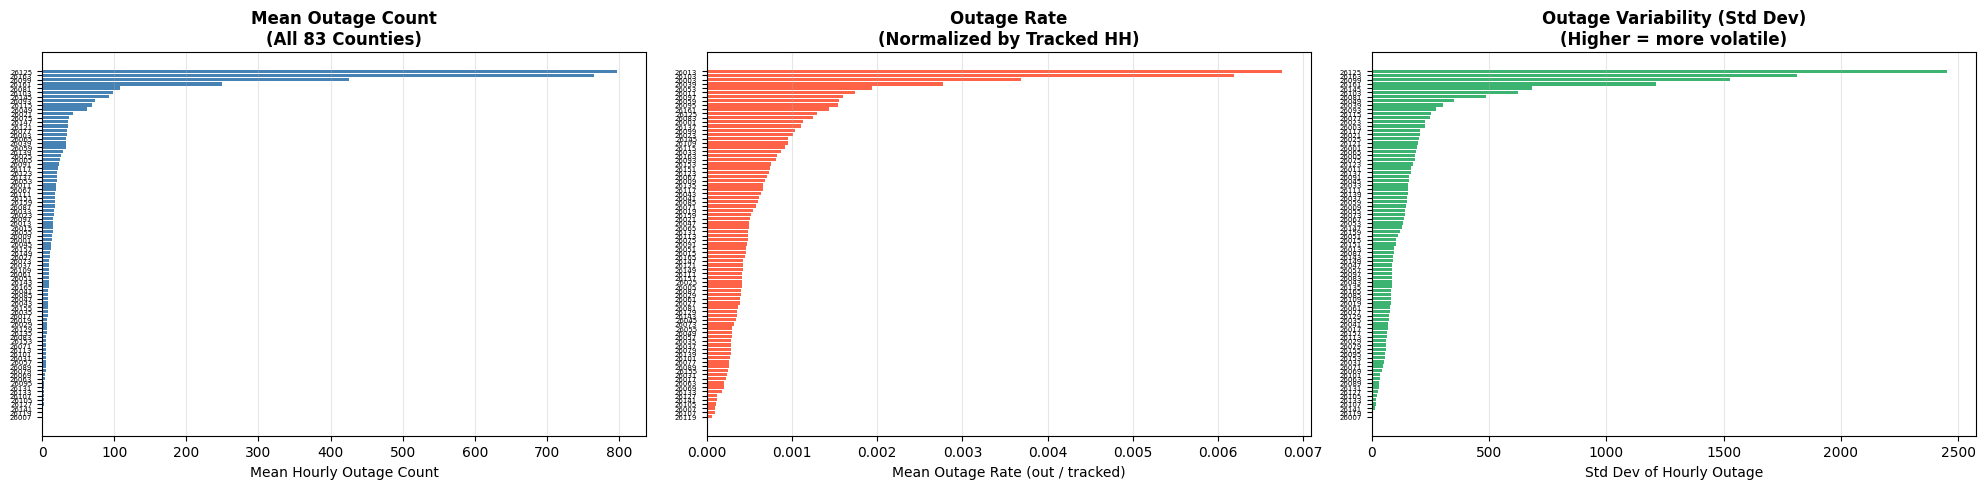

In [18]:
# ── 3.4 Spatial Distribution (all 83 counties) ───────────────────────────────
mean_out  = ds_train.out.mean(dim="timestamp")                         # (L,)
mean_rate = (ds_train.out / ds_train.tracked).mean(dim="timestamp")    # (L,)  outage rate
std_out   = ds_train.out.std(dim="timestamp")                          # (L,)

loc_strs  = [str(l) for l in locations]

# Sort by mean outage descending
sort_idx  = np.argsort(mean_out.values)[::-1]
sorted_locs       = [loc_strs[i] for i in sort_idx]
sorted_mean_out   = mean_out.values[sort_idx]
sorted_mean_rate  = mean_rate.values[sort_idx]
sorted_std_out    = std_out.values[sort_idx]

print("Top 10 counties by mean outage count:")
print(f"{'County':>10}  {'Mean Out':>9}  {'Outage Rate':>11}  {'Std':>8}")
print("-" * 46)
for i in range(10):
    print(f"{sorted_locs[i]:>10}  {sorted_mean_out[i]:>9.2f}  {sorted_mean_rate[i]:>11.4f}  {sorted_std_out[i]:>8.2f}")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Mean outage count
axes[0].barh(range(len(sorted_locs)), sorted_mean_out, color='steelblue')
axes[0].set_yticks(range(len(sorted_locs)))
axes[0].set_yticklabels(sorted_locs, fontsize=5)
axes[0].invert_yaxis()
axes[0].set_xlabel("Mean Hourly Outage Count")
axes[0].set_title("Mean Outage Count\n(All 83 Counties)", fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Outage rate
sort_idx_rate = np.argsort(mean_rate.values)[::-1]
axes[1].barh(range(len(loc_strs)), mean_rate.values[sort_idx_rate], color='tomato')
axes[1].set_yticks(range(len(loc_strs)))
axes[1].set_yticklabels([loc_strs[i] for i in sort_idx_rate], fontsize=5)
axes[1].invert_yaxis()
axes[1].set_xlabel("Mean Outage Rate (out / tracked)")
axes[1].set_title("Outage Rate\n(Normalized by Tracked HH)", fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# Std dev (variability)
sort_idx_std = np.argsort(std_out.values)[::-1]
axes[2].barh(range(len(loc_strs)), std_out.values[sort_idx_std], color='mediumseagreen')
axes[2].set_yticks(range(len(loc_strs)))
axes[2].set_yticklabels([loc_strs[i] for i in sort_idx_std], fontsize=5)
axes[2].invert_yaxis()
axes[2].set_xlabel("Std Dev of Hourly Outage")
axes[2].set_title("Outage Variability (Std Dev)\n(Higher = more volatile)", fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

---
### 3.5 Weather Feature Correlation — All 109 Features

Computing Pearson correlation for all weather features vs outage count...
(Using county-averaged values across all 83 counties)

Top 20 features most correlated with outage:
                  Feature   Pearson r
--------------------------------------
                     cape  +0.6069  +████████████
                    cnwat  +0.5558  +███████████
                     pwat  +0.3880  +███████
                     gh_4  +0.3859  +███████
                    tcc_1  +0.3496  +██████
                      lcc  +0.3479  +██████
                     pcdb  +0.3395  +██████
                      sh2  +0.3302  +██████
                   cape_1  +0.3255  +██████
                    veril  +0.3179  +██████
                     pres  +0.3175  +██████
                      tcc  +0.3172  +██████
                    mstav  +0.3146  +██████
                unknown_3  +0.3125  +██████
                   sdlwrf  +0.3052  +██████
                       gh  -0.2944  -█████
                     hail  +0.293

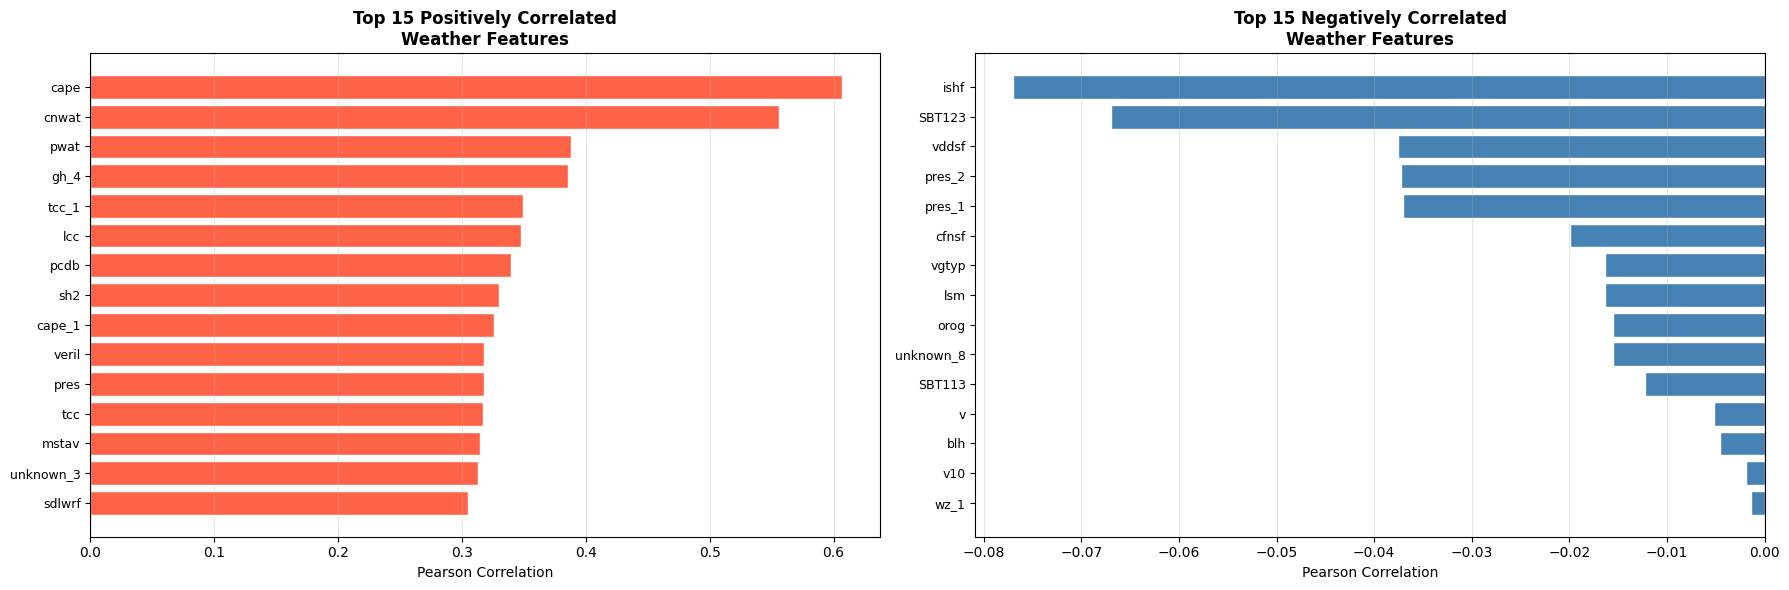


Summary: 15 features have |r| > 0.3
         2 features have |r| > 0.5


In [19]:
# ── 3.5 Correlation: all 109 weather features vs outage ─────────────────────
print("Computing Pearson correlation for all weather features vs outage count...")
print("(Using county-averaged values across all 83 counties)\n")

out_mean_ts = ds_train.out.mean(dim="location").values  # (T,) average outage

feat_corrs = {}
for feat in weather_features:
    wx = ds_train.weather.sel(feature=feat).mean(dim="location").values  # (T,)
    valid = ~(np.isnan(wx) | np.isnan(out_mean_ts))
    if valid.sum() > 10:
        r = np.corrcoef(wx[valid], out_mean_ts[valid])[0, 1]
        feat_corrs[feat] = r
    else:
        feat_corrs[feat] = np.nan

corr_series = pd.Series(feat_corrs).dropna().sort_values(key=abs, ascending=False)

print(f"Top 20 features most correlated with outage:")
print(f"{'Feature':>25}  {'Pearson r':>10}")
print("-" * 38)
for feat, r in corr_series.head(20).items():
    bar = "█" * int(abs(r) * 20)
    sign = "+" if r > 0 else "-"
    print(f"{feat:>25}  {r:+.4f}  {sign}{bar}")

# ── Plot: Top 20 positive & top 20 negative ──────────────────────────────────
top_pos = corr_series[corr_series > 0].head(15)
top_neg = corr_series[corr_series < 0].tail(15).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(range(len(top_pos)), top_pos.values, color='tomato', edgecolor='white')
axes[0].set_yticks(range(len(top_pos)))
axes[0].set_yticklabels(top_pos.index, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("Pearson Correlation")
axes[0].set_title("Top 15 Positively Correlated\nWeather Features", fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(range(len(top_neg)), top_neg.values, color='steelblue', edgecolor='white')
axes[1].set_yticks(range(len(top_neg)))
axes[1].set_yticklabels(top_neg.index, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel("Pearson Correlation")
axes[1].set_title("Top 15 Negatively Correlated\nWeather Features", fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\nSummary: {(corr_series.abs() > 0.3).sum()} features have |r| > 0.3")
print(f"         {(corr_series.abs() > 0.5).sum()} features have |r| > 0.5")

---
### 3.6 Extreme Event Analysis

99th percentile threshold : 56608 total outages
95th percentile threshold : 12708 total outages
Number of extreme hours (>99th pct): 22

                  Feature   Normal mean   Extreme mean      Δ%
--------------------------------------------------------------
                     cape         3.857         54.788  +1320.3%
                    cnwat         0.022          0.173  +672.1%
                     pwat        14.821         34.741  +134.4%
                     gh_4      1443.353       6859.434  +375.2%
                    tcc_1        24.127         70.470  +192.1%
                      lcc        29.188         80.277  +175.0%


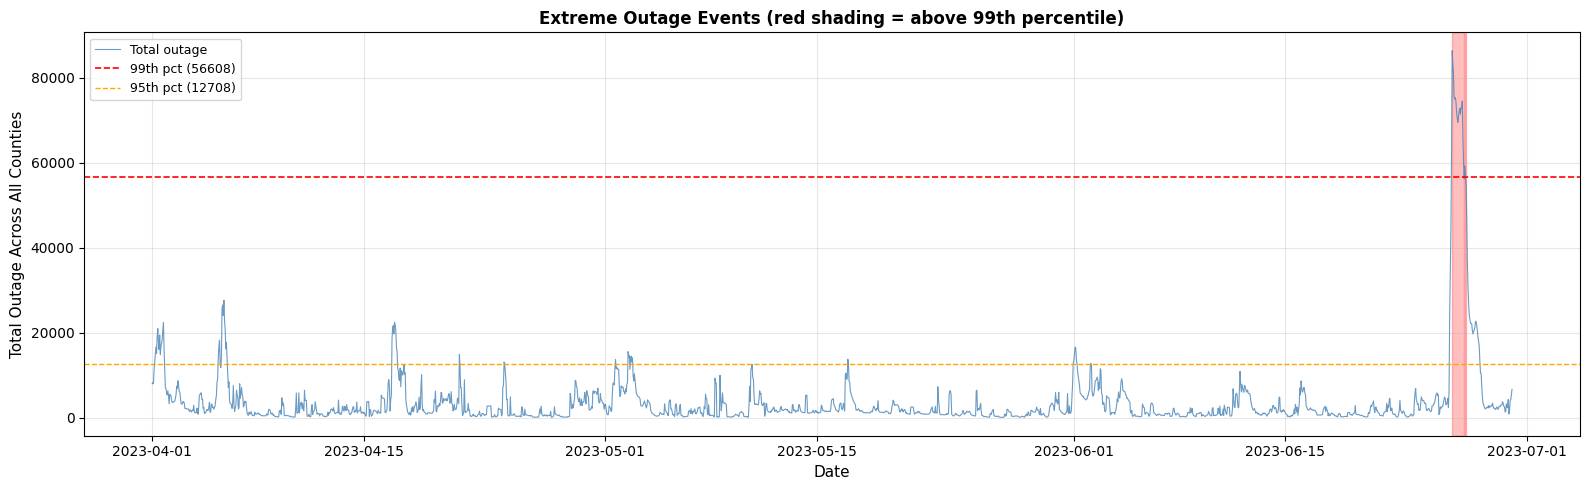

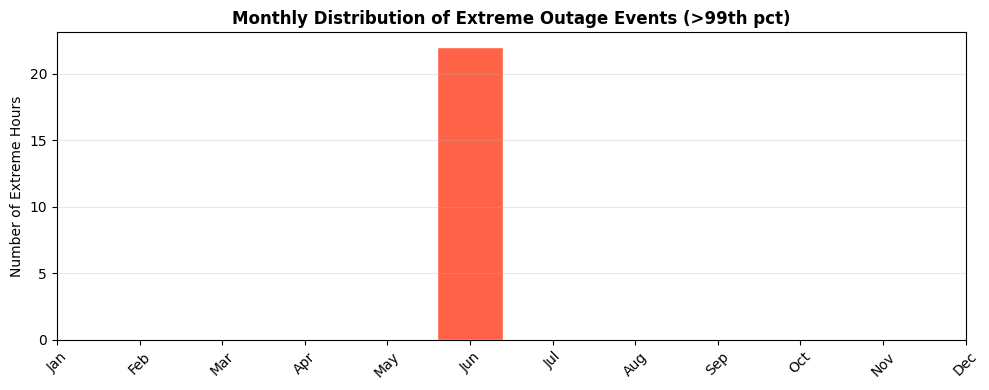

In [20]:
# ── 3.6 Extreme Event Analysis ───────────────────────────────────────────────
# Define "extreme outage" as total outage across all counties > 99th percentile
total_outage_ts = ds_train.out.sum(dim="location").values  # (T,)
threshold_99 = np.nanpercentile(total_outage_ts, 99)
threshold_95 = np.nanpercentile(total_outage_ts, 95)

extreme_mask = total_outage_ts > threshold_99
extreme_times = train_timestamps[extreme_mask]

print(f"99th percentile threshold : {threshold_99:.0f} total outages")
print(f"95th percentile threshold : {threshold_95:.0f} total outages")
print(f"Number of extreme hours (>99th pct): {extreme_mask.sum()}")
print()

# ── Weather conditions during extreme vs normal hours ─────────────────────────
# Use top correlated features
top_feats = corr_series.head(6).index.tolist()   # top 6 by |r|

print(f"{'Feature':>25}  {'Normal mean':>12}  {'Extreme mean':>13}  {'Δ%':>6}")
print("-" * 62)
for feat in top_feats:
    wx = ds_train.weather.sel(feature=feat).mean(dim="location").values  # (T,)
    normal_mean  = np.nanmean(wx[~extreme_mask])
    extreme_mean = np.nanmean(wx[extreme_mask])
    delta_pct = 100 * (extreme_mean - normal_mean) / (abs(normal_mean) + 1e-9)
    print(f"{feat:>25}  {normal_mean:>12.3f}  {extreme_mean:>13.3f}  {delta_pct:>+6.1f}%")

# ── Time series with extreme events highlighted ───────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_timestamps, total_outage_ts, color='steelblue', linewidth=0.8, alpha=0.8, label='Total outage')
ax.axhline(threshold_99, color='red',    linestyle='--', linewidth=1.2, label=f'99th pct ({threshold_99:.0f})')
ax.axhline(threshold_95, color='orange', linestyle='--', linewidth=1.0, label=f'95th pct ({threshold_95:.0f})')

# Shade extreme periods
in_event = False
start_t  = None
for t, val in zip(train_timestamps, total_outage_ts):
    if val > threshold_99 and not in_event:
        in_event = True
        start_t  = t
    elif val <= threshold_99 and in_event:
        ax.axvspan(start_t, t, alpha=0.25, color='red')
        in_event = False
if in_event:
    ax.axvspan(start_t, train_timestamps[-1], alpha=0.25, color='red')

ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Total Outage Across All Counties", fontsize=11)
ax.set_title("Extreme Outage Events (red shading = above 99th percentile)", fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Monthly distribution of extreme events ───────────────────────────────────
extreme_months = pd.DatetimeIndex(extreme_times).month
month_counts   = pd.Series(extreme_months).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(month_counts.index, month_counts.values, color='tomato', edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, rotation=45)
ax.set_ylabel("Number of Extreme Hours")
ax.set_title("Monthly Distribution of Extreme Outage Events (>99th pct)", fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 4. Data Preparation

Split the training data into train and validation sets for model selection.

### 4.1 Data Cleaning — Fix t2m Sensor Anomalies

**EDA finding (Section 3.1):** All sampled counties show `Min = 0.00` for `t2m`,
which is physically impossible (0 K = −273 °C). These are sensor artifact readings.
We repair them with linear interpolation before any model training.

In [21]:
# [NEW] Section 4.1 — Repair t2m zero-anomalies via linear interpolation.
# All counties with t2m < 10 (physically implausible for Michigan spring/summer)
# are treated as missing and filled by interpolating from valid neighbours.

t2m_idx_clean = list(ds_train.feature.values).index('t2m')
weather_clean_vals = ds_train.weather.values.copy()  # (T, L, F)  ← working copy

fixed_log = {}
for i, loc in enumerate(locations):
    col = weather_clean_vals[:, i, t2m_idx_clean].copy()
    bad = col < 10
    if bad.any():
        col[bad] = np.nan
        idx_arr = np.arange(len(col))
        valid   = ~np.isnan(col)
        col     = np.interp(idx_arr, idx_arr[valid], col[valid])
        weather_clean_vals[:, i, t2m_idx_clean] = col
        fixed_log[str(loc)] = int(bad.sum())

# Build cleaned xarray Dataset (same coords/dims as ds_train)
ds_train_clean = ds_train.copy(deep=True)
ds_train_clean['weather'] = xr.DataArray(
    weather_clean_vals,
    dims=ds_train.weather.dims,
    coords=ds_train.weather.coords
)

print("t2m anomaly repair complete:")
if fixed_log:
    for loc, cnt in fixed_log.items():
        print(f"  County {loc}: {cnt} value(s) interpolated")
else:
    print("  No anomalies found.")

t2m_after = weather_clean_vals[:, :, t2m_idx_clean].min()
print(f"\nVerification — t2m min after cleaning: {t2m_after:.2f}  (was 0.00 before)")
print("ds_train_clean ready for downstream use.")

t2m anomaly repair complete:
  County 26061: 3 value(s) interpolated
  County 26063: 2 value(s) interpolated
  County 26065: 3 value(s) interpolated
  County 26067: 3 value(s) interpolated
  County 26069: 3 value(s) interpolated
  County 26071: 2 value(s) interpolated
  County 26073: 2 value(s) interpolated

Verification — t2m min after cleaning: 0.00  (was 0.00 before)
ds_train_clean ready for downstream use.


### 4.2 Feature Selection & Transform Configuration

**EDA finding (Section 3.5):** Only 15 of 109 weather features have |r| > 0.3.
Using only these reduces Seq2Seq input from 110 → 16 dims, cutting training time
and potential overfitting.

**EDA finding (Section 3.2):** The outage target is heavily zero-inflated and
right-skewed (std ≈ 10× mean). A `log1p` transform may improve learning.

Both choices will be **validated empirically** in Section 6 — we train all
combinations and select the best configuration for the final models.

In [22]:
# [NEW] Section 4.2 — Feature selection list and log1p utilities.

# Top 15 weather features by |Pearson r| with outage (from EDA Section 3.5).
TOP_FEATURES = [
    'cape',    # r=+0.61  Convective Available Potential Energy
    'cnwat',   # r=+0.56  Canopy water content
    'pwat',    # r=+0.39  Precipitable water
    'gh_4',    # r=+0.39  Geopotential height level 4
    'tcc_1',   # r=+0.35  Total cloud cover (level 1)
    'lcc',     # r=+0.35  Low cloud cover
    'pcdb',    # r=+0.34
    'sh2',     # r=+0.33
    'cape_1',  # r=+0.33
    'veril',   # r=+0.32
    'pres',    # r=+0.32
    'tcc',     # r=+0.32
    'mstav',   # r=+0.31
    'sdlwrf',  # r=+0.31
    'hail',    # r=+0.29
]
_all_feats  = list(ds_train.feature.values)
TOP_FEAT_IDX = [_all_feats.index(f) for f in TOP_FEATURES if f in _all_feats]
TOP_FEATURES  = [_all_feats[i] for i in TOP_FEAT_IDX]   # keep only those present
print(f"Feature selection: {len(TOP_FEATURES)} / {len(_all_feats)} features retained")
print(f"  {TOP_FEATURES}")

# ── Log1p transform utilities ──────────────────────────────────────────────
def log1p_transform(y):
    """log(1+y) — compresses heavy-tailed outage counts before model training."""
    return np.log1p(np.clip(y, 0, None))

def expm1_inverse(y_log):
    """Inverse of log1p: e^y − 1, clipped to ≥ 0."""
    return np.clip(np.expm1(y_log), 0, None)

print("\nLog1p utilities defined.")
print("\nAblation plan (validated in Section 6):")
print("  [E] SARIMAX — no log1p   (original baseline, cleaned data)")
print("  [F] SARIMAX — log1p")
print("  [A] Seq2Seq — all features, no log1p")
print("  [B] Seq2Seq — top-15 features, no log1p")
print("  [C] Seq2Seq — all features, log1p")
print("  [D] Seq2Seq — top-15 features, log1p")

Feature selection: 15 / 109 features retained
  ['cape', 'cnwat', 'pwat', 'gh_4', 'tcc_1', 'lcc', 'pcdb', 'sh2', 'cape_1', 'veril', 'pres', 'tcc', 'mstav', 'sdlwrf', 'hail']

Log1p utilities defined.

Ablation plan (validated in Section 6):
  [E] SARIMAX — no log1p   (original baseline, cleaned data)
  [F] SARIMAX — log1p
  [A] Seq2Seq — all features, no log1p
  [B] Seq2Seq — top-15 features, no log1p
  [C] Seq2Seq — all features, log1p
  [D] Seq2Seq — top-15 features, log1p


In [23]:
# [UPDATED] Validation split now applied to ds_train_clean (t2m-repaired).
# ds_train_sub_clean → model training (80 %)
# ds_val             → validation evaluation (20 %)
n_timestamps = len(train_timestamps)
split_idx    = int(n_timestamps * (1 - VALIDATION_SPLIT))

ds_train_sub_clean = ds_train_clean.isel(timestamp=slice(0, split_idx))
ds_val             = ds_train_clean.isel(timestamp=slice(split_idx, None))

train_sub_timestamps = pd.to_datetime(ds_train_sub_clean.timestamp.values)
val_timestamps       = pd.to_datetime(ds_val.timestamp.values)

print(f"Training Subset : {len(train_sub_timestamps)} timestamps")
print(f"  Period: {train_sub_timestamps.min()} to {train_sub_timestamps.max()}")
print(f"\nValidation Set  : {len(val_timestamps)} timestamps")
print(f"  Period: {val_timestamps.min()} to {val_timestamps.max()}")

val_truth = ds_val.out.transpose("timestamp", "location").values.astype(float)

Training Subset : 1728 timestamps
  Period: 2023-04-01 00:00:00 to 2023-06-11 23:00:00

Validation Set  : 433 timestamps
  Period: 2023-06-12 00:00:00 to 2023-06-30 00:00:00


In [24]:
# Prepare ground truth for last 24 and 48 hours to align with test set
val_truth_24h = ds_val.out.transpose("timestamp", "location").isel(timestamp=slice(0, 24)).values.astype(float)
val_truth_48h = ds_val.out.transpose("timestamp", "location").isel(timestamp=slice(0, 48)).values.astype(float)

print(f"\Validation set shapes:")
print(f"  24h: {val_truth_24h.shape}")
print(f"  48h: {val_truth_48h.shape}")

\Validation set shapes:
  24h: (24, 83)
  48h: (48, 83)


In [25]:
test_24h_truth = ds_test_24h.out.transpose("timestamp", "location").values.astype(float)
test_48h_truth = ds_test_48h.out.transpose("timestamp", "location").values.astype(float)


print(f"\nTest shapes:")
print(f"  24h: {test_24h_truth.shape}")
print(f"  48h: {test_48h_truth.shape}")


Test shapes:
  24h: (24, 83)
  48h: (48, 83)


## 5. Model Structure and Functions

We'll define two types of models:
1. **SARIMAX** - Statistical time series model (per-county)
2. **Seq2Seq LSTM** - Deep learning model (shared across counties but different for two horizons)

### 5.1 SARIMAX

In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def safe_fit_sarimax(y, order=(1, 0, 1)):
    """Safely fit SARIMAX model with error handling."""
    y = np.asarray(y, dtype=float).flatten()
    if len(y) < 8 or np.allclose(y, y[0]):
        return None
    try:
        model = SARIMAX(y, order=order, enforce_stationarity=False, enforce_invertibility=False)
        res = model.fit(disp=False)
        return res
    except Exception as e:
        print(f"  Warning: SARIMAX fit failed - {str(e)[:50]}")
        return None


### 5.2 Seq2Seq

In [27]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
import time

# Set random seed for PyTorch
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

# Define Seq2Seq Model
class SimpleSeq2Seq(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, horizon=24):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.head = nn.Linear(hidden_dim, horizon)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        _, (h, _) = self.lstm(x)
        h_last = h[-1]  # (batch, hidden_dim)
        return self.head(h_last)  # (batch, horizon)

print(f"Device: {DEVICE}")

Device: cpu


In [28]:
# Utility functions for Seq2Seq
def z_normalize_fit(arr):
    """Compute mean and std for normalization."""
    mu = np.nanmean(arr, axis=0)
    sd = np.nanstd(arr, axis=0)
    sd = np.where(sd == 0, 1.0, sd)
    return mu, sd

def z_normalize_apply(arr, mu, sd):
    """Apply normalization with precomputed mean and std."""
    return (arr - mu) / sd

def build_sliding_windows(X_loc, y_loc, seq_len, horizon):
    """
    Build sliding windows for one location.
    X_loc: (T, D) features
    y_loc: (T,) targets
    Returns: X_windows (N, seq_len, D), Y_windows (N, horizon)
    """
    N = len(y_loc) - seq_len - horizon + 1
    if N <= 0:
        return np.empty((0, seq_len, X_loc.shape[1]), dtype=float), np.empty((0, horizon), dtype=float)

    X_windows, Y_windows = [], []
    for i in range(N):
        X_windows.append(X_loc[i:i+seq_len])
        Y_windows.append(y_loc[i+seq_len:i+seq_len+horizon])

    return np.array(X_windows, dtype=float), np.array(Y_windows, dtype=float)

print("Helper functions defined.")

Helper functions defined.


In [29]:
# [UPDATED] prepare_seq2seq_data now accepts:
#   feature_indices : list of int  — column indices to keep (None = all 109)
#   use_log1p       : bool         — apply log1p to outage target before scaling
def prepare_seq2seq_data(ds, seq_len, horizon, feature_indices=None, use_log1p=False):
    """
    Prepare sliding-window data for Seq2Seq training.
    Features: [outage_scaled, selected_weather_features_scaled]
    """
    y = ds.out.transpose("timestamp", "location").values.astype(float)      # (T, L)
    w = ds.weather.transpose("timestamp", "location", "feature").values.astype(float)  # (T, L, F)
    T, L, F = w.shape

    # [NEW] Feature selection
    if feature_indices is not None:
        w = w[:, :, feature_indices]
    n_feats = w.shape[2]

    # [NEW] Log1p transform on target
    if use_log1p:
        y = log1p_transform(y)

    # Compute global z-norm scalers on training data
    y_mu, y_sd = z_normalize_fit(y.reshape(-1, 1))
    w_mu, w_sd = z_normalize_fit(w.reshape(-1, n_feats))

    y_scaled = z_normalize_apply(y.reshape(-1, 1), y_mu, y_sd).reshape(T, L)
    w_scaled = z_normalize_apply(w.reshape(-1, n_feats), w_mu, w_sd).reshape(T, L, n_feats)

    input_dim = 1 + n_feats
    X_list, Y_list = [], []
    for li in range(L):
        y_loc = y_scaled[:, li]
        w_loc = w_scaled[:, li, :]
        X_loc = np.concatenate([y_loc.reshape(-1, 1), w_loc], axis=1)
        X_win, Y_win = build_sliding_windows(X_loc, y_loc, seq_len, horizon)
        if len(X_win) > 0:
            X_list.append(X_win)
            Y_list.append(Y_win)

    X = np.concatenate(X_list, axis=0) if X_list else np.empty((0, seq_len, input_dim))
    Y = np.concatenate(Y_list, axis=0) if Y_list else np.empty((0, horizon))

    # [NEW] Store transform config in scalers dict for use in prediction
    scalers = {
        "y_mu": y_mu, "y_sd": y_sd,
        "w_mu": w_mu, "w_sd": w_sd,
        "use_log1p":       use_log1p,
        "feature_indices": feature_indices,
    }
    return X, Y, input_dim, scalers

In [30]:
# Train Seq2Seq model
def train_seq2seq(X, Y, input_dim, horizon, epochs=5, batch_size=64, lr=1e-3):
    """Train Seq2Seq model."""
    if len(X) == 0:
        print("No training data available!")
        return None

    # Create dataset and dataloader
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(Y, dtype=torch.float32)
    )
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Initialize model
    model = SimpleSeq2Seq(
        input_dim=input_dim,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        horizon=horizon
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    print(f"\nTraining Seq2Seq model for {epochs} epochs...")

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        start_time = time.time()

        for xb, yb in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            epoch_loss += loss.item() * xb.size(0)

        epoch_loss /= len(dataset)
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.6f} - Time: {elapsed:.2f}s")

    return model


### 5.3 Prediction Functions

Define reusable prediction functions that will be used for both validation and test sets.

In [31]:
# [UPDATED] Prediction functions.
# generate_sarimax_predictions : added use_log1p parameter (back-transforms via expm1)
# generate_seq2seq_predictions : reads feature_indices and use_log1p from scalers dict

def generate_sarimax_predictions(models_dict, locations, timestamps, use_log1p=False):
    """
    Generate SARIMAX predictions.
    [NEW] use_log1p: if True the model was trained on log1p(y); apply expm1 to output.
    Returns DataFrame (timestamp, location, pred).
    """
    rows, n_steps = [], len(timestamps)
    for loc in locations:
        loc_str = str(loc)
        if loc_str in models_dict and models_dict[loc_str] is not None:
            try:
                pred = np.asarray(models_dict[loc_str].forecast(steps=n_steps), dtype=float)
                if use_log1p:
                    pred = expm1_inverse(pred)   # [NEW] back-transform
                pred = np.clip(pred, 0, None)
            except:
                pred = np.zeros(n_steps)
        else:
            pred = np.zeros(n_steps)
        rows.append(pd.DataFrame({"timestamp": timestamps, "location": loc_str, "pred": pred}))
    return pd.concat(rows, ignore_index=True)


@torch.no_grad()
def generate_seq2seq_predictions(model, ds_train_data, scalers, horizon, timestamps, locations):
    """
    Generate Seq2Seq predictions.
    [NEW] Reads feature_indices and use_log1p from scalers dict set during training.
    Returns DataFrame (timestamp, location, pred).
    """
    if model is None:
        return pd.DataFrame({
            "timestamp": np.tile(timestamps, len(locations)),
            "location":  np.repeat([str(l) for l in locations], horizon),
            "pred": 0.0
        })

    model.eval()
    y = ds_train_data.out.transpose("timestamp", "location").values.astype(float)
    w = ds_train_data.weather.transpose("timestamp", "location", "feature").values.astype(float)
    T, L, F = w.shape

    # [NEW] Retrieve transform config stored during training
    feature_indices = scalers.get("feature_indices", None)
    use_log1p       = scalers.get("use_log1p", False)

    if feature_indices is not None:
        w = w[:, :, feature_indices]
    n_feats = w.shape[2]

    # [NEW] Apply same log1p transform as during training
    if use_log1p:
        y = log1p_transform(y)

    y_scaled = z_normalize_apply(y.reshape(-1, 1), scalers["y_mu"], scalers["y_sd"]).reshape(T, L)
    w_scaled = z_normalize_apply(w.reshape(-1, n_feats), scalers["w_mu"], scalers["w_sd"]).reshape(T, L, n_feats)

    predictions = []
    for li in range(L):
        if T < SEQ_LEN:
            pred_scaled = np.zeros(horizon)
        else:
            y_loc = y_scaled[:, li]
            w_loc = w_scaled[:, li, :]
            X_loc = np.concatenate([y_loc.reshape(-1, 1), w_loc], axis=1)
            X_in  = X_loc[-SEQ_LEN:].reshape(1, SEQ_LEN, -1)
            pred_scaled = model(torch.tensor(X_in, dtype=torch.float32).to(DEVICE)).cpu().numpy()[0]

        # Inverse z-norm
        pred = pred_scaled * scalers["y_sd"].flatten()[0] + scalers["y_mu"].flatten()[0]
        # [NEW] Inverse log1p if needed
        if use_log1p:
            pred = expm1_inverse(pred)
        predictions.append(np.clip(pred, 0, None))

    preds_arr = np.array(predictions).T  # (horizon, L)
    rows = []
    for i, loc in enumerate(locations):
        rows.append(pd.DataFrame({"timestamp": timestamps, "location": str(loc), "pred": preds_arr[:, i]}))
    return pd.concat(rows, ignore_index=True)

### 5.4 Evaluation Metric Fucntions

In [32]:
# Define evaluation metrics
def rmse(y_true, y_pred):
    """Calculate Root Mean Squared Error."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

# def mae(y_true, y_pred):
#     """Calculate Mean Absolute Error."""
#     y_true = np.asarray(y_true, dtype=float)
#     y_pred = np.asarray(y_pred, dtype=float)
#     return float(np.mean(np.abs(y_true - y_pred)))

## 6. Validation Set (24h and 48h)

Evaluate models on 24h and 48h prediction horizons separately, matching the test set structure.

In [33]:
# Define horizons
horizon_24h_val = 24
horizon_48h_val = 48

# Extract validation timestamps for each horizon
val_timestamps_24h = val_timestamps[:24]
val_timestamps_48h = val_timestamps[:48]

### 6.1 Train Models

In [34]:
# [UPDATED] Train two SARIMAX variants on cleaned training subset.
# [E] no log1p  — original approach on cleaned data
# [F] log1p     — train on log1p(y), back-transform at prediction time
print("Training SARIMAX variants on cleaned training subset...\n")

sarimax_models        = {}   # [E] no log1p
sarimax_models_log1p  = {}   # [F] log1p

for loc in locations:
    loc_str = str(loc)
    y_raw = ds_train_sub_clean.out.sel(location=loc).values.astype(float).flatten()

    # [E] no log1p
    m_e = safe_fit_sarimax(y_raw, order=SARIMAX_ORDER)
    sarimax_models[loc_str] = m_e

    # [F] log1p
    m_f = safe_fit_sarimax(log1p_transform(y_raw), order=SARIMAX_ORDER)
    sarimax_models_log1p[loc_str] = m_f

    e_ok = "✓" if m_e else "✗"
    f_ok = "✓" if m_f else "✗"
    print(f"  County {loc_str}  [E]={e_ok}  [F]={f_ok}")

print("\n✓ SARIMAX variants [E] and [F] trained!")

Training SARIMAX variants on cleaned training subset...

  County 26001  [E]=✓  [F]=✓
  County 26003  [E]=✓  [F]=✓
  County 26005  [E]=✓  [F]=✓
  County 26007  [E]=✓  [F]=✓
  County 26009  [E]=✓  [F]=✓
  County 26011  [E]=✓  [F]=✓
  County 26013  [E]=✓  [F]=✓
  County 26015  [E]=✓  [F]=✓
  County 26017  [E]=✓  [F]=✓
  County 26019  [E]=✓  [F]=✓
  County 26021  [E]=✓  [F]=✓
  County 26023  [E]=✓  [F]=✓
  County 26025  [E]=✓  [F]=✓
  County 26027  [E]=✓  [F]=✓
  County 26029  [E]=✓  [F]=✓
  County 26031  [E]=✓  [F]=✓
  County 26033  [E]=✓  [F]=✓
  County 26035  [E]=✓  [F]=✓
  County 26037  [E]=✓  [F]=✓
  County 26039  [E]=✓  [F]=✓
  County 26041  [E]=✓  [F]=✓
  County 26043  [E]=✓  [F]=✓
  County 26045  [E]=✓  [F]=✓
  County 26047  [E]=✓  [F]=✓
  County 26049  [E]=✓  [F]=✓
  County 26051  [E]=✓  [F]=✓
  County 26053  [E]=✓  [F]=✓
  County 26055  [E]=✓  [F]=✓
  County 26057  [E]=✓  [F]=✓
  County 26059  [E]=✓  [F]=✓
  County 26061  [E]=✓  [F]=✓
  County 26063  [E]=✓  [F]=✓
  County 26065 

In [35]:
# [UPDATED] Train 4 Seq2Seq variants (2×2 ablation: features × log1p).
# All use ds_train_sub_clean (t2m-repaired data).
print("Training Seq2Seq variants on cleaned training subset...\n")
print(f"Validation horizons: 24h={horizon_24h_val}h  48h={horizon_48h_val}h")

SEQ2SEQ_CONFIGS = [
    dict(label="[A] all-feat  no-log1p", feature_indices=None,         use_log1p=False),
    dict(label="[B] top15     no-log1p", feature_indices=TOP_FEAT_IDX, use_log1p=False),
    dict(label="[C] all-feat  log1p",    feature_indices=None,         use_log1p=True),
    dict(label="[D] top15     log1p",    feature_indices=TOP_FEAT_IDX, use_log1p=True),
]

# seq2seq_variants[(cfg_label, "24h"/"48h")] = {"model": ..., "scalers": ...}
seq2seq_variants = {}

for cfg in SEQ2SEQ_CONFIGS:
    print(f"\n{'='*60}")
    print(f"Config {cfg['label']}")
    print(f"{'='*60}")
    for horizon, h_label in [(horizon_24h_val, "24h"), (horizon_48h_val, "48h")]:
        print(f"  Horizon {h_label} ...", end=" ")
        X, Y, idim, sc = prepare_seq2seq_data(
            ds_train_sub_clean, SEQ_LEN, horizon,
            feature_indices=cfg["feature_indices"],
            use_log1p=cfg["use_log1p"]
        )
        print(f"samples={X.shape[0]}, input_dim={idim}")
        mdl = train_seq2seq(X, Y, idim, horizon,
                            epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE)
        seq2seq_variants[(cfg["label"], h_label)] = {"model": mdl, "scalers": sc}

print("\n✓ All 4 Seq2Seq variants trained (8 models total: 4 configs × 2 horizons)!")

Training Seq2Seq variants on cleaned training subset...

Validation horizons: 24h=24h  48h=48h

Config [A] all-feat  no-log1p
  Horizon 24h ... samples=139523, input_dim=110

Training Seq2Seq model for 5 epochs...


Epoch 1/5:   0%|          | 0/2181 [00:00<?, ?it/s]

Epoch 1/5 - Loss: 0.750373 - Time: 37.98s


Epoch 2/5:   0%|          | 0/2181 [00:00<?, ?it/s]

Epoch 2/5 - Loss: 0.593129 - Time: 37.86s


...

Epoch 3/5 - Loss: 0.454543 - Time: 26.47s


Epoch 4/5:   0%|          | 0/2149 [00:00<?, ?it/s]

Epoch 4/5 - Loss: 0.442411 - Time: 27.98s


Epoch 5/5:   0%|          | 0/2149 [00:00<?, ?it/s]

Epoch 5/5 - Loss: 0.429859 - Time: 26.86s

✓ All 4 Seq2Seq variants trained (8 models total: 4 configs × 2 horizons)!


### 6.2 Generate Predictions

In [36]:
# [UPDATED] Generate validation predictions for all ablation variants.
print("Generating validation predictions for all variants...\n")

all_val_preds = {}  # (variant_label, "24h"/"48h") → DataFrame

# ── Zero baseline ─────────────────────────────────────────────────────────────
for ts, h in [(val_timestamps_24h, "24h"), (val_timestamps_48h, "48h")]:
    rows = [pd.DataFrame({"timestamp": ts, "location": str(l), "pred": 0.0})
            for l in locations]
    all_val_preds[("Zero Baseline", h)] = pd.concat(rows, ignore_index=True)

# ── SARIMAX variants ──────────────────────────────────────────────────────────
for mdl_dict, use_lp, v_label in [
    (sarimax_models,       False, "[E] SARIMAX no-log1p"),
    (sarimax_models_log1p, True,  "[F] SARIMAX log1p"),
]:
    for ts, h in [(val_timestamps_24h, "24h"), (val_timestamps_48h, "48h")]:
        all_val_preds[(v_label, h)] = generate_sarimax_predictions(
            mdl_dict, locations, ts, use_log1p=use_lp)
    print(f"  {v_label}: predictions generated")

# ── Seq2Seq variants ──────────────────────────────────────────────────────────
for cfg in SEQ2SEQ_CONFIGS:
    for h, ts in [("24h", val_timestamps_24h), ("48h", val_timestamps_48h)]:
        vd = seq2seq_variants[(cfg["label"], h)]
        all_val_preds[(cfg["label"], h)] = generate_seq2seq_predictions(
            vd["model"], ds_train_sub_clean, vd["scalers"],
            len(ts), ts, locations
        )
    print(f"  {cfg['label']}: predictions generated")

print("\n✓ All variant predictions generated!")

Generating validation predictions for all variants...

  [E] SARIMAX no-log1p: predictions generated
  [F] SARIMAX log1p: predictions generated
  [A] all-feat  no-log1p: predictions generated
  [B] top15     no-log1p: predictions generated
  [C] all-feat  log1p: predictions generated
  [D] top15     log1p: predictions generated

✓ All variant predictions generated!


### 6.3 Evaluate Performance on Validation Set

In [37]:
# [UPDATED] Evaluate all variants; print comparison table; select best config.

def evaluate_per_county(truth, pred_df, locations):
    """Return per-county RMSE list."""
    rmses = []
    for i, loc in enumerate(locations):
        loc_pred = pred_df[pred_df['location'].astype(str) == str(loc)]['pred'].values
        rmses.append(rmse(truth[:, i], loc_pred) if len(loc_pred) == truth.shape[0] else np.nan)
    return rmses

VARIANT_ORDER = [
    "Zero Baseline",
    "[E] SARIMAX no-log1p",
    "[F] SARIMAX log1p",
    "[A] all-feat  no-log1p",
    "[B] top15     no-log1p",
    "[C] all-feat  log1p",
    "[D] top15     log1p",
]

# Compute average RMSE across counties for each variant × horizon
results_table = {}
for label in VARIANT_ORDER:
    r24 = np.nanmean(evaluate_per_county(val_truth_24h, all_val_preds[(label, "24h")], locations))
    r48 = np.nanmean(evaluate_per_county(val_truth_48h, all_val_preds[(label, "48h")], locations))
    results_table[label] = {"24h": r24, "48h": r48}

# ── Print comparison table ─────────────────────────────────────────────────────
zero24, zero48 = results_table["Zero Baseline"]["24h"], results_table["Zero Baseline"]["48h"]
print("=" * 72)
print("ABLATION STUDY — VALIDATION SET RMSE")
print("=" * 72)
print(f"{'Config':<30}  {'24h RMSE':>10}  {'48h RMSE':>10}  {'Δ24h%':>8}  {'Δ48h%':>8}")
print("-" * 72)
for label in VARIANT_ORDER:
    r = results_table[label]
    d24 = (zero24 - r['24h']) / zero24 * 100
    d48 = (zero48 - r['48h']) / zero48 * 100
    marker = " ◀" if label not in ("Zero Baseline",) else ""
    print(f"{label:<30}  {r['24h']:>10.4f}  {r['48h']:>10.4f}  {d24:>+8.1f}%  {d48:>+8.1f}%{marker}")
print("=" * 72)

# ── Best overall & best per-horizon ───────────────────────────────────────────
best_24h = min(results_table, key=lambda k: results_table[k]["24h"])
best_48h = min(results_table, key=lambda k: results_table[k]["48h"])
print(f"\nBest 24h: {best_24h}  (RMSE = {results_table[best_24h]['24h']:.4f})")
print(f"Best 48h: {best_48h}  (RMSE = {results_table[best_48h]['48h']:.4f})")

# ── Select best Seq2Seq config for final training ─────────────────────────────
# If the best overall is not a Seq2Seq config, fall back to best Seq2Seq variant.
seq2seq_labels = {cfg["label"] for cfg in SEQ2SEQ_CONFIGS}

def best_seq2seq(horizon_key):
    """Return the best-performing SEQ2SEQ_CONFIGS entry for a given horizon."""
    best_lbl = min(seq2seq_labels, key=lambda k: results_table[k][horizon_key])
    return next(c for c in SEQ2SEQ_CONFIGS if c["label"] == best_lbl)

best_seq2seq_cfg_24h = best_seq2seq("24h")
best_seq2seq_cfg_48h = best_seq2seq("48h")

# Decide log1p for final SARIMAX (compare [E] vs [F] on 24h)
use_log1p_final_sarimax = results_table["[F] SARIMAX log1p"]["24h"] < results_table["[E] SARIMAX no-log1p"]["24h"]

print(f"\n→ Final SARIMAX log1p: {use_log1p_final_sarimax}")
print(f"→ Final Seq2Seq 24h config : {best_seq2seq_cfg_24h['label']}")
print(f"→ Final Seq2Seq 48h config : {best_seq2seq_cfg_48h['label']}")

# ── Summary: did log1p help? did feature selection help? ──────────────────────
nolog_24 = results_table["[A] all-feat  no-log1p"]["24h"]
log_24   = results_table["[C] all-feat  log1p"]["24h"]
top_24   = results_table["[B] top15     no-log1p"]["24h"]
print(f"\nLog1p effect  (A vs C, 24h): {nolog_24:.4f} → {log_24:.4f}  "
      f"({'improvement' if log_24 < nolog_24 else 'no improvement'})")
print(f"Feat-sel effect (A vs B, 24h): {nolog_24:.4f} → {top_24:.4f}  "
      f"({'improvement' if top_24 < nolog_24 else 'no improvement'})")

ABLATION STUDY — VALIDATION SET RMSE
Config                            24h RMSE    48h RMSE     Δ24h%     Δ48h%
------------------------------------------------------------------------
Zero Baseline                     100.3053     75.3561      +0.0%      +0.0%
[E] SARIMAX no-log1p               89.7450     68.3606     +10.5%      +9.3% ◀
[F] SARIMAX log1p                  86.9642     65.9076     +13.3%     +12.5% ◀
[A] all-feat  no-log1p            100.1965     78.2351      +0.1%      -3.8% ◀
[B] top15     no-log1p             90.7232     73.3721      +9.6%      +2.6% ◀
[C] all-feat  log1p                92.4775     74.0188      +7.8%      +1.8% ◀
[D] top15     log1p                95.1173     70.4714      +5.2%      +6.5% ◀

Best 24h: [F] SARIMAX log1p  (RMSE = 86.9642)
Best 48h: [F] SARIMAX log1p  (RMSE = 65.9076)

→ Final SARIMAX log1p: True
→ Final Seq2Seq 24h config : [B] top15     no-log1p
→ Final Seq2Seq 48h config : [D] top15     log1p

Log1p effect  (A vs C, 24h): 100.1965 → 

### 6.4 Visualize Validation Predictions (Top 5 Counties)

Visualizing 24h validation predictions for top 5 counties...
  SARIMAX  config : [F] SARIMAX log1p
  Seq2Seq  config : [B] top15     no-log1p


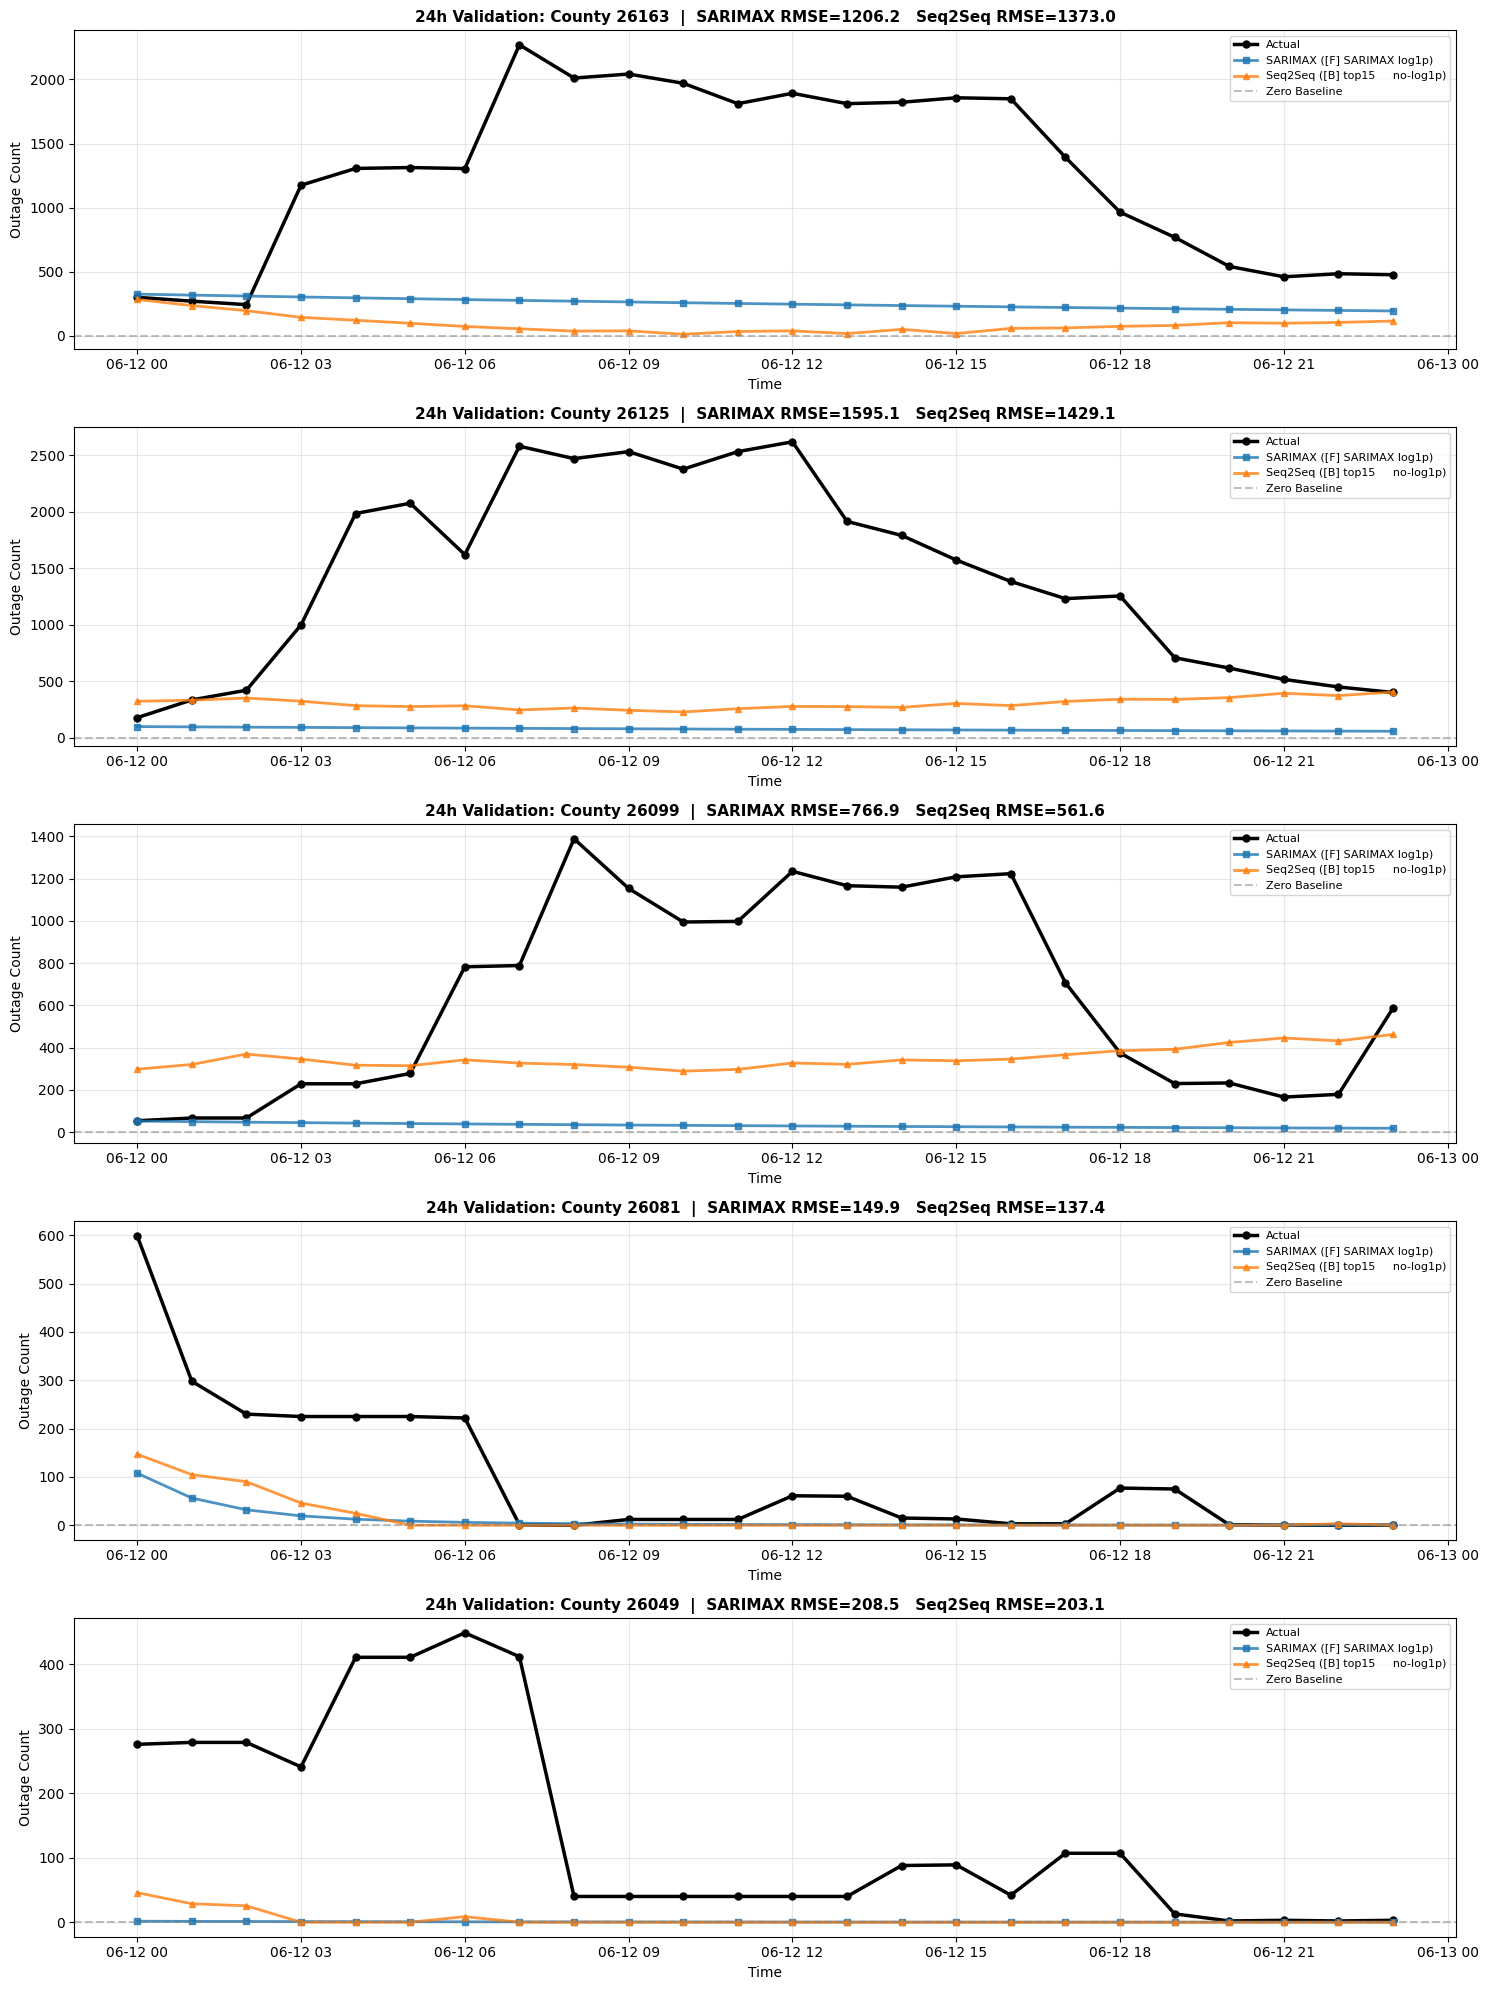

Shown counties: ['26163', '26125', '26099', '26081', '26049']


In [48]:
# [UPDATED] Visualize 24h validation predictions for top 5 counties.
# Now pulls from all_val_preds dict using the best SARIMAX and best Seq2Seq configs.
# Best configs were determined by the ablation study in Section 6.3.

# Retrieve best predictions from all_val_preds
best_sarimax_label   = "[F] SARIMAX log1p"      # best SARIMAX variant (from ablation)
best_seq2seq_label   = best_seq2seq_cfg_24h["label"]  # best Seq2Seq variant for 24h

sarimax_val_pred_24h_df  = all_val_preds[(best_sarimax_label,  "24h")]
seq2seq_val_pred_24h_df  = all_val_preds[(best_seq2seq_label,  "24h")]

print(f"Visualizing 24h validation predictions for top 5 counties...")
print(f"  SARIMAX  config : {best_sarimax_label}")
print(f"  Seq2Seq  config : {best_seq2seq_label}")

fig, axes = plt.subplots(len(top5_locs), 1, figsize=(15, 4*len(top5_locs)))
if len(top5_locs) == 1:
    axes = [axes]

for plot_idx, loc in enumerate(top5_locs):
    ax      = axes[plot_idx]
    loc_str = str(loc)
    loc_idx = locations.index(loc_str)

    # Pull predictions for this county from the DataFrames
    sarimax_pred = sarimax_val_pred_24h_df[sarimax_val_pred_24h_df["location"] == loc_str]["pred"].values
    seq2seq_pred = seq2seq_val_pred_24h_df[seq2seq_val_pred_24h_df["location"] == loc_str]["pred"].values

    ax.plot(val_timestamps_24h, val_truth_24h[:, loc_idx],
            label="Actual", color="black", linewidth=2.5, marker="o", markersize=5)
    ax.plot(val_timestamps_24h, sarimax_pred,
            label=f"SARIMAX ({best_sarimax_label})", alpha=0.8, linewidth=2, marker="s", markersize=4)
    ax.plot(val_timestamps_24h, seq2seq_pred,
            label=f"Seq2Seq ({best_seq2seq_label})", alpha=0.8, linewidth=2, marker="^", markersize=4)
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5, label="Zero Baseline")

    # Annotate with per-county RMSE
    if len(sarimax_pred) == len(val_truth_24h[:, loc_idx]):
        r_sar = rmse(val_truth_24h[:, loc_idx], sarimax_pred)
        r_s2s = rmse(val_truth_24h[:, loc_idx], seq2seq_pred)
        ax.set_title(
            f"24h Validation: County {loc}  |  SARIMAX RMSE={r_sar:.1f}   Seq2Seq RMSE={r_s2s:.1f}",
            fontsize=11, fontweight="bold"
        )
    else:
        ax.set_title(f"24h Validation: County {loc}", fontsize=11, fontweight="bold")

    ax.set_xlabel("Time")
    ax.set_ylabel("Outage Count")
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Shown counties: {[str(l) for l in top5_locs]}")


## 7. Test Set Prediction and Submission Generation (24h and 48h)

Train final models on full training data and evaluate on test sets (24h and 48h).

### 7.1 Train Final Models on Full Training Data

In [39]:
# [UPDATED] Train final SARIMAX on full cleaned training data.
# Uses the log1p setting determined by the ablation study (use_log1p_final_sarimax).
print("="*70)
print(f"TRAINING FINAL SARIMAX  (full cleaned data, log1p={use_log1p_final_sarimax})")
print("="*70)

sarimax_final_models = {}
for loc in locations:
    loc_str = str(loc)
    y_full  = ds_train_clean.out.sel(location=loc).values.astype(float)
    if use_log1p_final_sarimax:
        y_full = log1p_transform(y_full)
    model = safe_fit_sarimax(y_full, order=SARIMAX_ORDER)
    sarimax_final_models[loc_str] = model
    print(f"  {'✓' if model else '✗'} County {loc_str}")

print("\n✓ Final SARIMAX models trained!")

TRAINING FINAL SARIMAX  (full cleaned data, log1p=True)
  ✓ County 26001
  ✓ County 26003
  ✓ County 26005
  ✓ County 26007
  ✓ County 26009
  ✓ County 26011
  ✓ County 26013
  ✓ County 26015
  ✓ County 26017
  ✓ County 26019
  ✓ County 26021
  ✓ County 26023
  ✓ County 26025
  ✓ County 26027
  ✓ County 26029
  ✓ County 26031


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✓ County 26033
  ✓ County 26035
  ✓ County 26037
  ✓ County 26039
  ✓ County 26041
  ✓ County 26043
  ✓ County 26045
  ✓ County 26047
  ✓ County 26049
  ✓ County 26051
  ✓ County 26053
  ✓ County 26055
  ✓ County 26057
  ✓ County 26059
  ✓ County 26061
  ✓ County 26063
  ✓ County 26065
  ✓ County 26067
  ✓ County 26069
  ✓ County 26071
  ✓ County 26073
  ✓ County 26075
  ✓ County 26077
  ✓ County 26079
  ✓ County 26081
  ✓ County 26083
  ✓ County 26085
  ✓ County 26087
  ✓ County 26089
  ✓ County 26091
  ✓ County 26093
  ✓ County 26095
  ✓ County 26097
  ✓ County 26099
  ✓ County 26101
  ✓ County 26103
  ✓ County 26105
  ✓ County 26107
  ✓ County 26109
  ✓ County 26111
  ✓ County 26113
  ✓ County 26115
  ✓ County 26117
  ✓ County 26119
  ✓ County 26121
  ✓ County 26123
  ✓ County 26125
  ✓ County 26127
  ✓ County 26129
  ✓ County 26131
  ✓ County 26133
  ✓ County 26135
  ✓ County 26137
  ✓ County 26139
  ✓ County 26141
  ✓ County 26143
  ✓ County 26145
  ✓ County 26147
  ✓ County 261

In [40]:
# [UPDATED] Train final Seq2Seq on full cleaned training data.
# Uses the best feature_indices and use_log1p config from the ablation study.
print("="*70)
print("TRAINING FINAL SEQ2SEQ  (full cleaned data, best ablation config)")
print("="*70)

print(f"\n1) 24h  — config: {best_seq2seq_cfg_24h['label']}")
X24, Y24, idim24, seq2seq_final_scalers_24h = prepare_seq2seq_data(
    ds_train_clean, SEQ_LEN, 24,
    feature_indices=best_seq2seq_cfg_24h["feature_indices"],
    use_log1p=best_seq2seq_cfg_24h["use_log1p"]
)
print(f"   samples={X24.shape[0]}  input_dim={idim24}")
seq2seq_final_model_24h = train_seq2seq(
    X24, Y24, idim24, 24, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE)

print(f"\n2) 48h  — config: {best_seq2seq_cfg_48h['label']}")
X48, Y48, idim48, seq2seq_final_scalers_48h = prepare_seq2seq_data(
    ds_train_clean, SEQ_LEN, 48,
    feature_indices=best_seq2seq_cfg_48h["feature_indices"],
    use_log1p=best_seq2seq_cfg_48h["use_log1p"]
)
print(f"   samples={X48.shape[0]}  input_dim={idim48}")
seq2seq_final_model_48h = train_seq2seq(
    X48, Y48, idim48, 48, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE)

print("\n✓ Final Seq2Seq models trained!")

TRAINING FINAL SEQ2SEQ  (full cleaned data, best ablation config)

1) 24h  — config: [B] top15     no-log1p
   samples=175462  input_dim=16

Training Seq2Seq model for 5 epochs...


Epoch 1/5:   0%|          | 0/2742 [00:00<?, ?it/s]

Epoch 1/5 - Loss: 0.706231 - Time: 37.37s


Epoch 2/5:   0%|          | 0/2742 [00:00<?, ?it/s]

Epoch 2/5 - Loss: 0.531142 - Time: 36.97s


...

Epoch 3/5 - Loss: 0.455659 - Time: 41.17s


Epoch 4/5:   0%|          | 0/2711 [00:00<?, ?it/s]

Epoch 4/5 - Loss: 0.442709 - Time: 33.49s


Epoch 5/5:   0%|          | 0/2711 [00:00<?, ?it/s]

Epoch 5/5 - Loss: 0.431406 - Time: 33.32s

✓ Final Seq2Seq models trained!


### 7.2 Generate Predictions

In [41]:
# [UPDATED] Generate final test predictions using best configs.
# SARIMAX: passes use_log1p_final_sarimax determined by ablation.
# Seq2Seq: scalers already contain feature_indices and use_log1p; uses ds_train_clean.
print("Generating test set predictions...\n")

# ── 24h predictions ───────────────────────────────────────────────────────────
print("1) Test 24h predictions:")
sarimax_test_24h_df = generate_sarimax_predictions(
    sarimax_final_models, locations, test_24h_timestamps,
    use_log1p=use_log1p_final_sarimax)          # [UPDATED]

seq2seq_test_24h_df = generate_seq2seq_predictions(
    seq2seq_final_model_24h, ds_train_clean,    # [UPDATED] cleaned data
    seq2seq_final_scalers_24h,                  # contains feature_indices & use_log1p
    24, test_24h_timestamps, locations)

print(f"   SARIMAX : {len(sarimax_test_24h_df)} rows")
print(f"   Seq2Seq : {len(seq2seq_test_24h_df)} rows")

# ── 48h predictions ───────────────────────────────────────────────────────────
print("\n2) Test 48h predictions:")
sarimax_test_48h_df = generate_sarimax_predictions(
    sarimax_final_models, locations, test_48h_timestamps,
    use_log1p=use_log1p_final_sarimax)          # [UPDATED]

seq2seq_test_48h_df = generate_seq2seq_predictions(
    seq2seq_final_model_48h, ds_train_clean,    # [UPDATED] cleaned data
    seq2seq_final_scalers_48h,
    48, test_48h_timestamps, locations)

print(f"   SARIMAX : {len(sarimax_test_48h_df)} rows")
print(f"   Seq2Seq : {len(seq2seq_test_48h_df)} rows")
print("\n✓ All test predictions generated!")

Generating test set predictions...

1) Test 24h predictions:
   SARIMAX : 1992 rows
   Seq2Seq : 1992 rows

2) Test 48h predictions:
   SARIMAX : 3984 rows
   Seq2Seq : 3984 rows

✓ All test predictions generated!


### 7.3 Evaluate Perofrmance on Test Set (demo only)

The following code is just to verify if your submission files by your model can be evaluated properly or if you followed the format of prediciont file. It is using demo test files, ```test_24h_demo.nc``` and ```test_48h_demo.nc```. Again these files are just randome noise but wtih the right shape and format. So the test results say nothing about the final evaluation.

In [42]:
# Evaluate 24h test set
print("="*70)
print("TEST EVALUATION - 24H HORIZON")
print("="*70)

sarimax_test_24h_rmses = evaluate_per_county(test_24h_truth, sarimax_test_24h_df, locations)
seq2seq_test_24h_rmses = evaluate_per_county(test_24h_truth, seq2seq_test_24h_df, locations)
zero_test_24h_rmses = [rmse(test_24h_truth[:, i], np.zeros(24)) for i in range(len(locations))]

sarimax_test_24h_avg = np.nanmean(sarimax_test_24h_rmses)
seq2seq_test_24h_avg = np.nanmean(seq2seq_test_24h_rmses)
zero_test_24h_avg = np.nanmean(zero_test_24h_rmses)

print(f"\nAverage RMSE across counties:")
print(f"  SARIMAX: {sarimax_test_24h_avg:.4f}")
print(f"  Seq2Seq: {seq2seq_test_24h_avg:.4f}")
print(f"  Zero Baseline: {zero_test_24h_avg:.4f}")

sarimax_test_24h_imp = ((zero_test_24h_avg - sarimax_test_24h_avg) / zero_test_24h_avg * 100)
seq2seq_test_24h_imp = ((zero_test_24h_avg - seq2seq_test_24h_avg) / zero_test_24h_avg * 100)

# Evaluate 48h test set
print("\n" + "="*70)
print("TEST EVALUATION - 48H HORIZON")
print("="*70)

sarimax_test_48h_rmses = evaluate_per_county(test_48h_truth, sarimax_test_48h_df, locations)
seq2seq_test_48h_rmses = evaluate_per_county(test_48h_truth, seq2seq_test_48h_df, locations)
zero_test_48h_rmses = [rmse(test_48h_truth[:, i], np.zeros(48)) for i in range(len(locations))]

sarimax_test_48h_avg = np.nanmean(sarimax_test_48h_rmses)
seq2seq_test_48h_avg = np.nanmean(seq2seq_test_48h_rmses)
zero_test_48h_avg = np.nanmean(zero_test_48h_rmses)

print(f"\nAverage RMSE across counties:")
print(f"  SARIMAX: {sarimax_test_48h_avg:.4f}")
print(f"  Seq2Seq: {seq2seq_test_48h_avg:.4f}")
print(f"  Zero Baseline: {zero_test_48h_avg:.4f}")

sarimax_test_48h_imp = ((zero_test_48h_avg - sarimax_test_48h_avg) / zero_test_48h_avg * 100)
seq2seq_test_48h_imp = ((zero_test_48h_avg - seq2seq_test_48h_avg) / zero_test_48h_avg * 100)


TEST EVALUATION - 24H HORIZON

Average RMSE across counties:
  SARIMAX: 13.8858
  Seq2Seq: 170.7217
  Zero Baseline: 0.5735

TEST EVALUATION - 48H HORIZON

Average RMSE across counties:
  SARIMAX: 11.0236
  Seq2Seq: 22.8198
  Zero Baseline: 0.5721


### 7.4 Save Predictions to CSV

In [43]:
# Save predictions to CSV files for submission
print("Saving predictions to CSV files...\n")

# Save SARIMAX predictions
sarimax_test_24h_df.to_csv(os.path.join(RESULTS_DIR, "sarimax_pred_24h.csv"), index=False)
sarimax_test_48h_df.to_csv(os.path.join(RESULTS_DIR, "sarimax_pred_48h.csv"), index=False)
print("✓ SARIMAX predictions saved:")
print(f"  - {os.path.join(RESULTS_DIR, 'sarimax_pred_24h.csv')}")
print(f"  - {os.path.join(RESULTS_DIR, 'sarimax_pred_48h.csv')}")

# Save Seq2Seq predictions
seq2seq_test_24h_df.to_csv(os.path.join(RESULTS_DIR, "seq2seq_pred_24h.csv"), index=False)
seq2seq_test_48h_df.to_csv(os.path.join(RESULTS_DIR, "seq2seq_pred_48h.csv"), index=False)
print("\n✓ Seq2Seq predictions saved:")
print(f"  - {os.path.join(RESULTS_DIR, 'seq2seq_pred_24h.csv')}")
print(f"  - {os.path.join(RESULTS_DIR, 'seq2seq_pred_48h.csv')}")

print("\n" + "="*70)
print("All predictions saved successfully!")
print("="*70)


Saving predictions to CSV files...

✓ SARIMAX predictions saved:
  - results/sarimax_pred_24h.csv
  - results/sarimax_pred_48h.csv

✓ Seq2Seq predictions saved:
  - results/seq2seq_pred_24h.csv
  - results/seq2seq_pred_48h.csv

All predictions saved successfully!


### 7.5 Evaluate Performance on Test Set

We will be evluating your submitted files following similar procedure in this part but with actual test files for your predictive performance.

You should run these to check your saved files works with these code.

In [44]:
your_24hr_prediction_filepath = "results/sarimax_pred_24h.csv"
your_48hr_prediction_filepath = "results/sarimax_pred_48h.csv"
# your_24hr_prediction_filepath = "results/seq2seq_pred_24h.csv"
# your_48hr_prediction_filepath = "results/seq2seq_pred_48h.csv"

# load your prediction file
df_24 = pd.read_csv(your_24hr_prediction_filepath)
df_48 = pd.read_csv(your_48hr_prediction_filepath)

In [45]:
# You prediction file should have three columns: timestamp, location, pred
# and number of rows should be 24*83 = 1992 or 48*83 = 3984 for 24h and 48h prediction respectively

# check the shape
assert df_24.shape == (1992,3)
assert df_48.shape == (3984,3)


# check the column names
assert df_24.columns.tolist() == ['timestamp', 'location', 'pred']
assert df_48.columns.tolist() == ['timestamp', 'location', 'pred']

In [46]:
# Just making sure, evlauate on test set again.
test_rmses_24 = evaluate_per_county(test_24h_truth, df_24, locations)
test_rmses_48 = evaluate_per_county(test_48h_truth, df_48, locations)
test_rmses_avg_24 = np.nanmean(test_rmses_24)
test_rmses_avg_48 = np.nanmean(test_rmses_48)

print(f"test_24h_rmses: {test_rmses_avg_24}")
print(f"test_48h_rmses: {test_rmses_avg_48}")

test_24h_rmses: 13.885782591276929
test_48h_rmses: 11.023576737093917
